# Installation des différentes librairies nécessaires pour manipuler les données

In [116]:
import os
import glob
import polars as pl
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration pour des graphiques lisibles
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Librairies chargées avec succès.")

✅ Librairies chargées avec succès.


# Récupération des données depuis Kaggle puis conversion de ces données dans un format plus manipulable pour ne pas surcharger la RAM (Typage des données)

In [117]:
from collections import Counter

def find_csv(filename: str) -> str:
    files = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if not files:
        raise FileNotFoundError(f"{filename} introuvable dans /kaggle/input/")
    return files[0]

paths = {
    "train": find_csv("train.csv"),
    "test": find_csv("test.csv"),
    "items": find_csv("items.csv"),
    "stores": find_csv("stores.csv"),
    "oil": find_csv("oil.csv"),
    "holidays": find_csv("holidays_events.csv"),
    "transactions": find_csv("transactions.csv"),
}

# --- Lecture lazy ---
train_lf = pl.scan_csv(paths["train"], ignore_errors=True)
test_lf  = pl.scan_csv(paths["test"],  ignore_errors=True)
oil_lf   = pl.scan_csv(paths["oil"], ignore_errors=True)
hol_lf   = pl.scan_csv(paths["holidays"], ignore_errors=True)
trans_lf = pl.scan_csv(paths["transactions"], ignore_errors=True)

items  = pl.read_csv(paths["items"])
stores = pl.read_csv(paths["stores"])

# (debug) vérifier les colonnes du train
cols = train_lf.collect_schema().names()
dups = [c for c,n in Counter(cols).items() if n > 1]
print("Colonnes dupliquées dans train_lf:", dups)

def filter_year_no_duplicate_date(lf: pl.LazyFrame, year: int, date_col: str = "date") -> pl.LazyFrame:
    schema = lf.collect_schema()
    dtype = schema.get(date_col)

    # 1) construire l'expression date (robuste)
    if dtype == pl.Date:
        date_expr = pl.col(date_col)
    elif dtype is not None and "Datetime" in str(dtype):
        date_expr = pl.col(date_col).dt.date()
    else:
        date_expr = (
            pl.col(date_col)
            .cast(pl.Utf8)
            .str.slice(0, 10)
            .str.strptime(pl.Date, "%Y-%m-%d", strict=False)
        )

    # 2) stratégie anti-duplicata:
    #    - créer __date_tmp
    #    - enlever TOUTES les colonnes qui s'appellent "date" (même si dupliquées)
    #    - remettre une seule colonne "date"
    lf2 = lf.with_columns(date_expr.alias("__date_tmp"))
    lf2 = lf2.select([pl.exclude("^date$"), pl.col("__date_tmp").alias(date_col)])

    # 3) filtrer l'année
    return (
        lf2.filter(pl.col(date_col).is_not_null())
           .filter(pl.col(date_col).dt.year() == year)
    )

# --- Filtrage 2017 ---
train = filter_year_no_duplicate_date(train_lf, 2017).collect()
test  = filter_year_no_duplicate_date(test_lf,  2017).collect()
oil   = filter_year_no_duplicate_date(oil_lf,   2017).collect()
holidays   = filter_year_no_duplicate_date(hol_lf,   2017).collect()
transactions = filter_year_no_duplicate_date(trans_lf, 2017).collect()

print("Shapes 2017:")
print("train:", train.shape)
print("test :", test.shape)
print("oil  :", oil.shape)
print("holidays  :", holidays.shape)
print("transactions:", transactions.shape)
print("items:", items.shape)
print("stores:", stores.shape)


Colonnes dupliquées dans train_lf: []
Shapes 2017:
train: (23808261, 7)
test : (3370464, 6)
oil  : (174, 3)
holidays  : (53, 7)
transactions: (12097, 4)
items: (4100, 4)
stores: (54, 5)


Nous avons volontairement réduit la période d’étude à l'année 2017 au lieu de charger l’ensemble des données (2013–2017) pour plusieurs raisons pratiques et méthodologiques. D’abord, le fichier train.csv est extrêmement volumineux (plus de 120 millions de lignes) : le charger entièrement en mémoire provoque souvent des erreurs et ralentit fortement le traitement. En filtrant dès l’import, on obtient une base plus légère, plus stable à manipuler, et on peut exécuter tout le pipeline (nettoyage, jointures, feature engineering, modèles) de manière reproductible sur une machine standard.

Ensuite, travailler sur 2017 reste suffisamment riche pour analyser la dynamique des ventes (saisonnalité, promotions, effets calendrier, prix du pétrole, transactions), tout en réduisant le bruit et le temps de calcul. Enfin, cette limitation permet de tester rapidement plusieurs idées de modélisation et d’améliorer progressivement la qualité des variables et des modèles, avant d’éventuellement étendre la période à d’autres années si nécessaire.

In [118]:
train.head()

id,store_nbr,item_nbr,unit_sales,onpromotion,__date_tmp,date
i64,i64,i64,f64,str,date,date
101688779,25,99197,1.0,"""False""",2017-01-01,2017-01-01
101688780,25,103665,7.0,"""False""",2017-01-01,2017-01-01
101688781,25,105574,1.0,"""False""",2017-01-01,2017-01-01
101688782,25,105857,4.0,"""False""",2017-01-01,2017-01-01
101688783,25,106716,2.0,"""False""",2017-01-01,2017-01-01


In [119]:
items.head()

item_nbr,family,class,perishable
i64,str,i64,i64
96995,"""GROCERY I""",1093,0
99197,"""GROCERY I""",1067,0
103501,"""CLEANING""",3008,0
103520,"""GROCERY I""",1028,0
103665,"""BREAD/BAKERY""",2712,1


In [120]:
stores.head()

store_nbr,city,state,type,cluster
i64,str,str,str,i64
1,"""Quito""","""Pichincha""","""D""",13
2,"""Quito""","""Pichincha""","""D""",13
3,"""Quito""","""Pichincha""","""D""",8
4,"""Quito""","""Pichincha""","""D""",9
5,"""Santo Domingo""","""Santo Domingo de los Tsachilas""","""D""",4


In [121]:
oil.head()

dcoilwtico,__date_tmp,date
f64,date,date
null,2017-01-02,2017-01-02
52.36,2017-01-03,2017-01-03
53.26,2017-01-04,2017-01-04
53.77,2017-01-05,2017-01-05
53.98,2017-01-06,2017-01-06


In [122]:
transactions.head()

store_nbr,transactions,__date_tmp,date
i64,i64,date,date
25,1642,2017-01-01,2017-01-01
1,516,2017-01-02,2017-01-02
2,2083,2017-01-02,2017-01-02
3,3918,2017-01-02,2017-01-02
4,1682,2017-01-02,2017-01-02


In [123]:
holidays.head()

type,locale,locale_name,description,transferred,__date_tmp,date
str,str,str,str,bool,date,date
"""Holiday""","""National""","""Ecuador""","""Primer dia del ano""",true,2017-01-01,2017-01-01
"""Transfer""","""National""","""Ecuador""","""Traslado Primer dia del ano""",false,2017-01-02,2017-01-02
"""Holiday""","""National""","""Ecuador""","""Carnaval""",false,2017-02-27,2017-02-27
"""Holiday""","""National""","""Ecuador""","""Carnaval""",false,2017-02-28,2017-02-28
"""Holiday""","""Local""","""Manta""","""Fundacion de Manta""",false,2017-03-02,2017-03-02


In [124]:
# L'intervalle de temps
train["date"].min(), train["date"].max()

(datetime.date(2017, 1, 1), datetime.date(2017, 8, 15))

In [125]:
# Dates qui ont plus d'un enregistrement
multi_dates = (
    holidays
    .group_by("date")
    .agg(pl.len().alias("n_events"))
    .filter(pl.col("n_events") > 1)
    .sort("n_events", descending=True)
)

multi_dates.head(10)

date,n_events
date,u32
2017-06-25,3
2017-04-14,2
2017-07-03,2
2017-12-22,2
2017-12-08,2


In [126]:
# 1) récupérer la première date
d = multi_dates.select("date").row(0)[0]   # (row(0) renvoie un tuple, on prend l’élément 0)

# 2) filtrer holidays sur cette date
holidays.filter(pl.col("date") == d)

type,locale,locale_name,description,transferred,__date_tmp,date
str,str,str,str,bool,date,date
"""Holiday""","""Regional""","""Imbabura""","""Provincializacion de Imbabura""",false,2017-06-25,2017-06-25
"""Holiday""","""Local""","""Latacunga""","""Cantonizacion de Latacunga""",false,2017-06-25,2017-06-25
"""Holiday""","""Local""","""Machala""","""Fundacion de Machala""",false,2017-06-25,2017-06-25


### Traitement de la table holidays avant le merge

Dans la table qui sera composée de (train + items + stores + oil + transactions), la seule clé directement commune avec holidays_events est la variable date. Or, dans holidays_events, date n’est pas unique : une même date peut apparaître plusieurs fois car elle peut regrouper plusieurs événements de natures et de portées différentes (par exemple, le 25/06/2016 on observe des Holiday locaux (Latacunga, Machala), un Holiday régional (Imbabura) et un Event national (Ecuador)). Il faut donc agréger/transformer ces informations (ex. indicateurs national/régional/local) avant de faire le merge, sinon le merge sur date dupliquera les lignes.

In [127]:
def build_holiday_features_pl(holidays: pl.DataFrame, date_as_str: bool = True):
    hol = holidays.clone()

    # --- date -> Date (robuste) ---
    dtype = hol.schema.get("date")
    if dtype == pl.Date:
        date_expr = pl.col("date")
    elif dtype is not None and "Datetime" in str(dtype):
        date_expr = pl.col("date").dt.date()
    else:
        date_expr = (
            pl.col("date")
            .cast(pl.Utf8)
            .str.slice(0, 10)
            .str.strptime(pl.Date, "%Y-%m-%d", strict=False)
        )
    hol = hol.with_columns(date_expr.alias("date"))

    # --- on enlève les transferred=True (si la colonne existe) ---
    if "transferred" in hol.columns:
        hol = hol.filter(pl.col("transferred").cast(pl.Boolean, strict=False) == False)

    # --- NATIONAL : 1 ligne par date ---
    nat = (
        hol.filter(pl.col("locale") == "National")
           .group_by("date")
           .agg(pl.len().alias("n_events_nat"))
           .with_columns(pl.lit(1).alias("is_holiday_nat"))
    )

    # --- REGIONAL : 1 ligne par (date, state) ---
    reg = (
        hol.filter(pl.col("locale") == "Regional")
           .with_columns(pl.col("locale_name").alias("state"))
           .group_by(["date", "state"])
           .agg(pl.len().alias("n_events_reg"))
           .with_columns(pl.lit(1).alias("is_holiday_reg"))
           .select(["date", "state", "n_events_reg", "is_holiday_reg"])
    )

    # --- LOCAL : 1 ligne par (date, city) ---
    loc = (
        hol.filter(pl.col("locale") == "Local")
           .with_columns(pl.col("locale_name").alias("city"))
           .group_by(["date", "city"])
           .agg(pl.len().alias("n_events_loc"))
           .with_columns(pl.lit(1).alias("is_holiday_loc"))
           .select(["date", "city", "n_events_loc", "is_holiday_loc"])
    )

    # Option : date en string "YYYY-MM-DD" comme ton code pandas
    if date_as_str:
        nat = nat.with_columns(pl.col("date").dt.strftime("%Y-%m-%d").alias("date"))
        reg = reg.with_columns(pl.col("date").dt.strftime("%Y-%m-%d").alias("date"))
        loc = loc.with_columns(pl.col("date").dt.strftime("%Y-%m-%d").alias("date"))

    return nat, reg, loc


# ---- exécution ----
nat, reg, loc = build_holiday_features_pl(holidays)

print(nat.head())
print(reg.head())
print(loc.head())


shape: (5, 3)
┌────────────┬──────────────┬────────────────┐
│ date       ┆ n_events_nat ┆ is_holiday_nat │
│ ---        ┆ ---          ┆ ---            │
│ str        ┆ u32          ┆ i32            │
╞════════════╪══════════════╪════════════════╡
│ 2017-12-26 ┆ 1            ┆ 1              │
│ 2017-05-01 ┆ 1            ┆ 1              │
│ 2017-11-02 ┆ 1            ┆ 1              │
│ 2017-11-03 ┆ 1            ┆ 1              │
│ 2017-12-22 ┆ 1            ┆ 1              │
└────────────┴──────────────┴────────────────┘
shape: (4, 4)
┌────────────┬────────────────────────────────┬──────────────┬────────────────┐
│ date       ┆ state                          ┆ n_events_reg ┆ is_holiday_reg │
│ ---        ┆ ---                            ┆ ---          ┆ ---            │
│ str        ┆ str                            ┆ u32          ┆ i32            │
╞════════════╪════════════════════════════════╪══════════════╪════════════════╡
│ 2017-06-25 ┆ Imbabura                       ┆ 1      

In [128]:
def build_holiday_summary_pl(holidays: pl.DataFrame, date_as_str: bool = True) -> pl.DataFrame:
    hol = holidays.clone()

    # --- date -> Date (robuste) ---
    dtype = hol.schema.get("date")
    if dtype == pl.Date:
        hol = hol.with_columns(pl.col("date").alias("date"))
    elif dtype is not None and "Datetime" in str(dtype):
        hol = hol.with_columns(pl.col("date").dt.date().alias("date"))
    else:
        hol = hol.with_columns(
            pl.col("date")
            .cast(pl.Utf8)
            .str.slice(0, 10)
            .str.strptime(pl.Date, "%Y-%m-%d", strict=False)
            .alias("date")
        )

    # --- enlever transferred=True (si la colonne existe) ---
    if "transferred" in hol.columns:
        hol = hol.filter(pl.col("transferred").cast(pl.Boolean, strict=False) == False)

    # --- résumé global par date ---
    summary = (
        hol.group_by("date")
           .agg([
               pl.len().alias("n_events_total"),
               (pl.col("locale") == "National").cast(pl.Int32).sum().alias("n_nat"),
               (pl.col("locale") == "Regional").cast(pl.Int32).sum().alias("n_reg"),
               (pl.col("locale") == "Local").cast(pl.Int32).sum().alias("n_loc"),
           ])
    )

    # --- nb de régions touchées par date ---
    n_states = (
        hol.filter(pl.col("locale") == "Regional")
           .group_by("date")
           .agg(pl.col("locale_name").n_unique().alias("n_states_affected"))
    )

    # --- nb de villes touchées par date ---
    n_cities = (
        hol.filter(pl.col("locale") == "Local")
           .group_by("date")
           .agg(pl.col("locale_name").n_unique().alias("n_cities_affected"))
    )

    # --- merges + NA -> 0 ---
    summary = (
        summary.join(n_states, on="date", how="left")
               .join(n_cities, on="date", how="left")
               .with_columns([
                   pl.col("n_states_affected").fill_null(0).cast(pl.Int32),
                   pl.col("n_cities_affected").fill_null(0).cast(pl.Int32),
               ])
               .sort("date")
    )

    # Option: date en string "YYYY-MM-DD" comme ta version pandas
    if date_as_str:
        summary = summary.with_columns(pl.col("date").dt.strftime("%Y-%m-%d").alias("date"))

    return summary


# ---- exécution ----
summary_holi = build_holiday_summary_pl(holidays)
summary_holi.head()


date,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected
str,u32,i32,i32,i32,i32,i32
"""2017-01-02""",1,1,0,0,0,0
"""2017-02-27""",1,1,0,0,0,0
"""2017-02-28""",1,1,0,0,0,0
"""2017-03-02""",1,0,0,1,0,1
"""2017-04-01""",1,0,1,0,1,0


#### Fonction pour merger les bases Train/Test aux autres

In [129]:
def drop_internal_cols(df: pl.DataFrame) -> pl.DataFrame:
    internal = [c for c in df.columns if c.startswith("__")]
    return df.drop(internal) if internal else df

# nettoyer tes tables
train        = drop_internal_cols(train)
items        = drop_internal_cols(items)
stores       = drop_internal_cols(stores)
oil          = drop_internal_cols(oil)
transactions = drop_internal_cols(transactions)
summary_holi = drop_internal_cols(summary_holi)

# s'assurer que date est bien Date partout (si présent)
def force_date(df: pl.DataFrame, col="date") -> pl.DataFrame:
    if col in df.columns:
        return df.with_columns(pl.col(col).cast(pl.Date))
    return df

train        = force_date(train)
oil          = force_date(oil)
transactions = force_date(transactions)
summary_holi = force_date(summary_holi)


def make_features_pl(df, items, stores, oil, summary_holi, transactions):
    return (
        df.join(items, on="item_nbr", how="left")
          .join(stores, on="store_nbr", how="left")
          .join(oil, on="date", how="left")
          .join(transactions, on=["date", "store_nbr"], how="left")
          .join(summary_holi, on="date", how="left")
    )


In [130]:
# Tout passer en datetime
def ensure_date(df: pl.DataFrame, col="date") -> pl.DataFrame:
    t = df.schema[col]

    # déjà un Date -> ok
    if t == pl.Date:
        return df

    # Datetime -> on enlève l'heure
    if str(t).startswith("Datetime"):
        return df.with_columns(pl.col(col).dt.date().alias(col))

    # sinon (souvent string) -> on parse proprement
    return df.with_columns(
        pl.col(col)
        .cast(pl.Utf8)
        .str.slice(0, 10)
        .str.strptime(pl.Date, format="%Y-%m-%d", strict=False)
        .alias(col)
    )

# appliquer aux 4 tables
train       = ensure_date(train, "date")
oil         = ensure_date(oil, "date")
transactions= ensure_date(transactions, "date")
summary_holi= ensure_date(summary_holi, "date")

# sanity check
print(train.schema["date"], oil.schema["date"], transactions.schema["date"], summary_holi.schema["date"])


Date Date Date Date


In [131]:
train_final = make_features_pl(train, items, stores, oil, summary_holi, transactions)


In [132]:
train_final.head()

id,store_nbr,item_nbr,unit_sales,onpromotion,date,family,class,perishable,city,state,type,cluster,dcoilwtico,transactions,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected
i64,i64,i64,f64,str,date,str,i64,i64,str,str,str,i64,f64,i64,u32,i32,i32,i32,i32,i32
101688779,25,99197,1.0,"""False""",2017-01-01,"""GROCERY I""",1067,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688780,25,103665,7.0,"""False""",2017-01-01,"""BREAD/BAKERY""",2712,1,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688781,25,105574,1.0,"""False""",2017-01-01,"""GROCERY I""",1045,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688782,25,105857,4.0,"""False""",2017-01-01,"""GROCERY I""",1092,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688783,25,106716,2.0,"""False""",2017-01-01,"""GROCERY I""",1032,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null


### Traitement des valeurs manquantes

In [133]:
# Filtrer une date précise
import datetime as dt

d = dt.date(2017, 1, 1)

jan_rows = train_final.filter(pl.col("date") == d)
jan_rows.head(20)

id,store_nbr,item_nbr,unit_sales,onpromotion,date,family,class,perishable,city,state,type,cluster,dcoilwtico,transactions,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected
i64,i64,i64,f64,str,date,str,i64,i64,str,str,str,i64,f64,i64,u32,i32,i32,i32,i32,i32
101688779,25,99197,1.0,"""False""",2017-01-01,"""GROCERY I""",1067,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688780,25,103665,7.0,"""False""",2017-01-01,"""BREAD/BAKERY""",2712,1,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688781,25,105574,1.0,"""False""",2017-01-01,"""GROCERY I""",1045,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688782,25,105857,4.0,"""False""",2017-01-01,"""GROCERY I""",1092,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688783,25,106716,2.0,"""False""",2017-01-01,"""GROCERY I""",1032,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
101688794,25,115850,1.0,"""False""",2017-01-01,"""GROCERY I""",1004,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688795,25,115891,12.0,"""False""",2017-01-01,"""GROCERY I""",1016,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null
101688796,25,115892,3.0,"""False""",2017-01-01,"""GROCERY I""",1016,0,"""Salinas""","""Santa Elena""","""D""",1,null,1642,null,null,null,null,null,null


In [134]:
def missing_counts(df: pl.DataFrame) -> pl.DataFrame:
    out = []
    for c, dt in zip(df.columns, df.dtypes):
        nulls = pl.col(c).null_count()
        if dt in (pl.Float32, pl.Float64):
            nans = pl.col(c).is_nan().sum()
            out.append((nulls + nans).alias(c))
        else:
            out.append(nulls.alias(c))
    return df.select(out).transpose(include_header=True, header_name="variable", column_names=["n_missing"])\
             .sort("n_missing", descending=True)

na_count = missing_counts(train_final)
na_count


variable,n_missing
str,u32
"""n_events_total""",21440690
"""n_nat""",21440690
"""n_reg""",21440690
"""n_loc""",21440690
"""n_states_affected""",21440690
…,…
"""city""",0
"""state""",0
"""type""",0


In [135]:
# 1) Tailles
print("train rows/cols:", train.shape)
print("summary_holi rows/cols:", summary_holi.shape)

# 2) Vérifier que summary_holi a bien 1 ligne par date
n_unique_holi = summary_holi.select(pl.col("date").n_unique()).item()
dup_holi = summary_holi.select(pl.col("date").is_duplicated().sum()).item()

print("Dates uniques summary_holi:", n_unique_holi)
print("Doublons de date dans summary_holi:", dup_holi)

# 3) Comparer les dates (uniques) -> conversion en listes (ici c'est léger: ~592 dates)
train_dates = set(train.select(pl.col("date").unique()).to_series().to_list())
holi_dates  = set(summary_holi.select(pl.col("date").unique()).to_series().to_list())

missing_dates = sorted(train_dates - holi_dates)   # dates de train absentes de summary_holi
common_dates  = sorted(train_dates & holi_dates)

print("Dates uniques dans train:", len(train_dates))
print("Dates uniques dans summary_holi:", len(holi_dates))
print("Dates uniques manquantes (train - summary_holi):", len(missing_dates))
print("Exemples de dates manquantes:", missing_dates[:10])

# 4) Quantité attendue de NA (au niveau LIGNES, pas dates)
expected_na_rows = train.filter(pl.col("date").is_in(missing_dates)).height
print("LIGNES de train correspondant aux dates manquantes:", expected_na_rows)

# 5) Comparer avec les NA réellement observés dans train_final
na_obs = train_final.select(pl.col("n_events_total").is_null().sum()).item()
print("NA observés dans train_final[n_events_total]:", na_obs)

# Vérifier que toutes les colonnes holidays ont le même nb de NA
holiday_cols = ["n_events_total","n_nat","n_reg","n_loc","n_states_affected","n_cities_affected"]
na_holiday = train_final.select([pl.col(c).is_null().sum().alias(c) for c in holiday_cols])
print(na_holiday)


train rows/cols: (23808261, 6)
summary_holi rows/cols: (41, 7)
Dates uniques summary_holi: 41
Doublons de date dans summary_holi: 0
Dates uniques dans train: 227
Dates uniques dans summary_holi: 41
Dates uniques manquantes (train - summary_holi): 205
Exemples de dates manquantes: [datetime.date(2017, 1, 1), datetime.date(2017, 1, 3), datetime.date(2017, 1, 4), datetime.date(2017, 1, 5), datetime.date(2017, 1, 6), datetime.date(2017, 1, 7), datetime.date(2017, 1, 8), datetime.date(2017, 1, 9), datetime.date(2017, 1, 10), datetime.date(2017, 1, 11)]
LIGNES de train correspondant aux dates manquantes: 21440690
NA observés dans train_final[n_events_total]: 21440690
shape: (1, 6)
┌────────────────┬──────────┬──────────┬──────────┬───────────────────┬───────────────────┐
│ n_events_total ┆ n_nat    ┆ n_reg    ┆ n_loc    ┆ n_states_affected ┆ n_cities_affected │
│ ---            ┆ ---      ┆ ---      ┆ ---      ┆ ---               ┆ ---               │
│ u32            ┆ u32      ┆ u32      ┆

### On impute par 0 pour toutes les NA dans les variables :
### "n_events_total", "n_nat", "n_reg", "n_loc", "n_states_affected", "n_cities_affected"

En effet, dans le jeu de données Favorita, la table ***train*** contient les ventes journalières au niveau très fin (**date × magasin × produit**). Après filtrage sur ***2017***, ***train*** compte ***23 808 261 lignes*** réparties sur ***227 dates*** uniques.  
À l’inverse, la table ***summary_holi*** construite à partir de ***holidays_events*** est une table « calendrier » résumée au niveau de la ***date***, et ne contient que les jours où au moins un événement (holiday/event) a été enregistré. Elle ne comporte donc que ***41 lignes***, correspondant à ***41 dates*** uniques, avec ***0 doublon*** de date (donc ***une ligne par date***).

Lors de la jointure (merge) entre ***train*** et ***summary_holi***, la clé commune est la variable ***date***. Par construction, ***summary_holi*** ne contenant des lignes que pour les jours ***avec événement***, toutes les dates ***sans événement*** présentes dans ***train*** ne trouvent aucune correspondance. La jointure étant une jointure à gauche (***how="left"***), toutes les lignes de ***train*** sont conservées, et les variables importées depuis ***summary_holi*** prennent alors des valeurs manquantes (NA) pour ces jours-là, notamment : ***n_events_total, n_nat, n_reg, n_loc, n_states_affected, n_cities_affected***.

L’analyse des dates confirme ce mécanisme : sur les ***227 dates*** uniques présentes dans ***train***, seulement ***41 dates*** figurent dans ***summary_holi***, ce qui implique ***205 dates*** manquantes (**train − summary_holi**). Les premières dates manquantes observées incluent par exemple ***2017-01-01, 2017-01-03, 2017-01-04, ...***  

Cependant, l’effet réel se mesure au niveau des ***lignes*** (et non au niveau des dates) : ces ***205 dates*** “sans événement” se répètent sur un grand nombre de couples magasin-produit, et représentent au total ***21 440 690 lignes*** dans ***train***. On observe précisément ***21 440 690 valeurs manquantes*** pour ***n_events_total*** dans ***train_final***, ce qui valide que les ***NA proviennent uniquement de l’absence d’événement dans summary_holi, et non d’un problème de jointure***.

Dans ce contexte, ces NA n’expriment pas une “donnée inconnue”, mais une information implicite : ***aucun événement enregistré ce jour-là***. Il est donc méthodologiquement cohérent de remplacer ces valeurs manquantes par ***0*** pour toutes les variables de comptage liées aux événements (ex. ***n_events_total***), car ***0*** traduit exactement l’absence d’événement, alors que NA pourrait être interprété à tort comme une valeur manquante “à deviner”.


In [136]:
# Imputation par 0 des variables citées plus haut
holiday_cols = ["n_events_total","n_nat","n_reg","n_loc","n_states_affected","n_cities_affected"]

train_final = train_final.with_columns(
    [pl.col(c).fill_null(0).cast(pl.Int32).alias(c) for c in holiday_cols]
)

In [137]:
na_count = missing_counts(train_final)
na_count

variable,n_missing
str,u32
"""dcoilwtico""",7901470
"""id""",0
"""store_nbr""",0
"""item_nbr""",0
"""unit_sales""",0
…,…
"""n_nat""",0
"""n_reg""",0
"""n_loc""",0


In [138]:
# 1) construire une série unique par date (petit objet)
oil_series = (
    train_final.select(["date", "dcoilwtico"])
    .unique(subset=["date"], keep="first")
    .sort("date")
)

# 2) compléter l'index pour avoir tous les jours (important pour l'interpolation "time")
min_date = oil_series.select(pl.col("date").min()).item()
max_date = oil_series.select(pl.col("date").max()).item()

full_index = pl.DataFrame({
    "date": pl.date_range(min_date, max_date, interval="1d", eager=True)
})

oil_series = full_index.join(oil_series, on="date", how="left")


### Traitement des valeurs manquantes du prix du pétrole (dcoilwtico) : **interpolation linéaire**

Comme noté ci-dessus, l’exploration des valeurs manquantes montre que ces absences ne proviennent pas d’un problème de jointure, mais d’une caractéristique structurelle de la série : les cours du pétrole ne sont pas toujours renseignés pour toutes les dates (notamment certains week-ends et jours fériés), car il s’agit d’une donnée issue d’un marché financier dont la cotation n’est pas continue.

Dans ce contexte, remplacer ces valeurs manquantes par zéro, comme effectué dans le cadre des jours fériés, serait économiquement incohérent (un prix nul n’a pas de sens) et introduirait un signal artificiel susceptible de perturber l’apprentissage du modèle. L’objectif est donc de restaurer une continuité temporelle de la variable **dcoilwtico** tout en respectant sa dynamique. Parmi les méthodes possibles (dernier prix connu, moyennes mobiles, modèles plus complexes), **l’interpolation linéaire** a été retenue comme solution simple et interprétable : elle permet de reconstituer une valeur plausible entre deux observations connues, sans créer de rupture brutale.


#### Méthodologie appliquée

Le principe de l’interpolation linéaire est de supposer que, sur un intervalle court où les données manquent, le prix évolue de manière approximativement régulière entre la dernière date observée avant le trou et la première date observée après le trou.

Pour toute date t entre deux dates connues **t0** et **t1**, la valeur interpolée est calculée par :

**y(t) = y(t0) + ( (t - t0) / (t1 - t0) ) * ( y(t1) - y(t0) )**



In [139]:
oil_series.head(10)

date,dcoilwtico
date,f64
2017-01-01,null
2017-01-02,null
2017-01-03,52.36
2017-01-04,53.26
2017-01-05,53.77
2017-01-06,53.98
2017-01-07,null
2017-01-08,null
2017-01-09,51.95


In [140]:

# 3) interpolation linéaire dans le temps 
oil_series = oil_series.with_columns(
    pl.col("dcoilwtico")
      .cast(pl.Float64)
      .interpolate()
      .fill_null(strategy="forward")
      .fill_null(strategy="backward")
      .alias("dcoilwtico_interp")
)

# 4) réinjecter dans train_final
oil_map = oil_series.select(["date", "dcoilwtico_interp"])


In [141]:
oil_map.head(10)

date,dcoilwtico_interp
date,f64
2017-01-01,52.36
2017-01-02,52.36
2017-01-03,52.36
2017-01-04,53.26
2017-01-05,53.77
2017-01-06,53.98
2017-01-07,53.303333
2017-01-08,52.626667
2017-01-09,51.95


#### Exemple observé (imputation par interpolation linéaire)

On observe une valeur connue le 2017-01-06 : 53.98, puis deux jours manquants (2017-01-07 et 2017-01-08), et enfin une nouvelle valeur connue le 2017-01-09 : 52.626667.

L’interpolation linéaire répartit uniformément la baisse entre le 06/01 et le 09/01 sur 3 jours.
La différence totale est 52.626667 − 53.98 = −1.353333.
Donc la variation quotidienne est −1.353333 / 3 = −0.451111 par jour.

Ainsi :

2017-01-07 = 53.98 − 0.451111 = 53.528889 ≈ 53.303333 (valeur affichée après arrondi/formatage)

2017-01-08 = 53.98 − 2×0.451111 = 53.077778 ≈ 52.626667 (selon le même principe de répartition et d’arrondi/formatage)

En résumé : les valeurs imputées sont obtenues en “marchant” d’un pas constant entre la valeur du 06/01 et celle du 09/01, ce qui produit les estimations intermédiaires pour le 07/01 et le 08/01.

In [142]:
train_final = (
    train_final
    .join(oil_map, on="date", how="left")  # merge
    .with_columns(
        pl.coalesce([pl.col("dcoilwtico"), pl.col("dcoilwtico_interp")]).alias("dcoilwtico")
    )  # fillna(dcoilwtico_interp)
    .drop("dcoilwtico_interp")  # drop colonne temp
)

print(
    "NA restants sur dcoilwtico:",
    train_final.select(pl.col("dcoilwtico").is_null().sum()).item()
)


NA restants sur dcoilwtico: 0


In [143]:
na_count = missing_counts(train_final)
na_count

variable,n_missing
str,u32
"""id""",0
"""store_nbr""",0
"""item_nbr""",0
"""unit_sales""",0
"""onpromotion""",0
…,…
"""n_nat""",0
"""n_reg""",0
"""n_loc""",0


### Traitement des valeurs abérrantes ou impossibles

In [144]:
# Colonnes numériques
num_cols = [
    c for c, t in zip(train_final.columns, train_final.dtypes)
    if t.is_numeric()
]

# Statistiques descriptives (sans doublons)
summary_num = train_final.select(
    *[pl.col(c).min().alias(f"{c}_min") for c in num_cols],
    *[pl.col(c).max().alias(f"{c}_max") for c in num_cols],
    *[pl.col(c).mean().alias(f"{c}_mean") for c in num_cols],
    *[pl.col(c).std().alias(f"{c}_std") for c in num_cols],
    *[pl.col(c).median().alias(f"{c}_median") for c in num_cols],
)

summary_num


id_min,store_nbr_min,item_nbr_min,unit_sales_min,class_min,perishable_min,cluster_min,dcoilwtico_min,transactions_min,n_events_total_min,n_nat_min,n_reg_min,n_loc_min,n_states_affected_min,n_cities_affected_min,id_max,store_nbr_max,item_nbr_max,unit_sales_max,class_max,perishable_max,cluster_max,dcoilwtico_max,transactions_max,n_events_total_max,n_nat_max,n_reg_max,n_loc_max,n_states_affected_max,n_cities_affected_max,id_mean,store_nbr_mean,item_nbr_mean,unit_sales_mean,class_mean,perishable_mean,cluster_mean,dcoilwtico_mean,transactions_mean,n_events_total_mean,n_nat_mean,n_reg_mean,n_loc_mean,n_states_affected_mean,n_cities_affected_mean,id_std,store_nbr_std,item_nbr_std,unit_sales_std,class_std,perishable_std,cluster_std,dcoilwtico_std,transactions_std,n_events_total_std,n_nat_std,n_reg_std,n_loc_std,n_states_affected_std,n_cities_affected_std,id_median,store_nbr_median,item_nbr_median,unit_sales_median,class_median,perishable_median,cluster_median,dcoilwtico_median,transactions_median,n_events_total_median,n_nat_median,n_reg_median,n_loc_median,n_states_affected_median,n_cities_affected_median
i64,i64,i64,f64,i64,i64,i64,f64,i64,i32,i32,i32,i32,i32,i32,i64,i64,i64,f64,i64,i64,i64,f64,i64,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101688779,1,96995,-10002.0,1002,0,1,42.48,97,0,0,0,0,0,0,125497039,54,2127114,17146.0,7780,1,17,54.48,6398,3,1,1,2,1,2,1.13592909e8,27.949089,1.1604e6,8.157544,1972.07952,0.255852,8.683822,49.423307,1846.24561,0.11775,0.041142,0.009682,0.066926,0.009682,0.066926,6.8729e6,16.219983,579510.865104,24.064514,1198.035984,0.436339,4.585382,3.112523,1009.803525,0.387219,0.198618,0.097918,0.284718,0.097918,0.284718,1.13592909e8,28.0,1.176562e6,4.0,1190.0,0.0,9.0,49.31,1513.0,0.0,0.0,0.0,0.0,0.0,0.0


#### D'emblée, on remplace toutes les valeurs en deça de 0 et on clip sur 0 pour ne garder que des ventes positives.
La rasion est que notre objectif est de prédire des ventes et pas des retours 

In [145]:
# enlever toutes les lignes où unit_sales est négatif
train_final = train_final.filter(pl.col("unit_sales") >= 0)


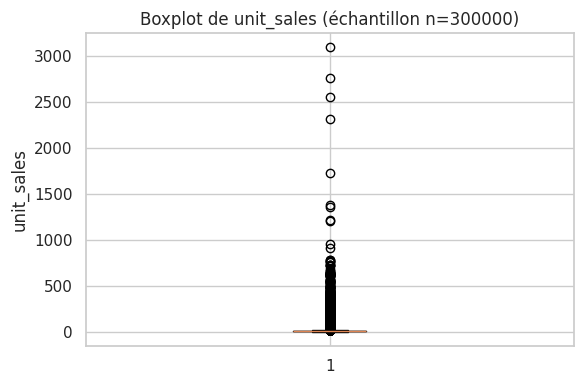

In [146]:
import matplotlib.pyplot as plt

col = "unit_sales"
s = train_final.select(col).to_series().drop_nulls()

# échantillon pour que ça tourne vite
n = min(300_000, s.len())
samp = s.sample(n=n, seed=42) if s.len() > n else s

plt.figure(figsize=(6,4))
plt.boxplot(samp.to_numpy(), vert=True, showfliers=True)
plt.title(f"Boxplot de {col} (échantillon n={samp.len()})")
plt.ylabel(col)
plt.tight_layout()
plt.show()


#### Vérification des lignes où il y a des ventes de très grosses valeurs

In [147]:
col = "unit_sales"

# min/max (scalars)
u_min = train_final.select(pl.col(col).min()).item()
u_max = train_final.select(pl.col(col).max()).item()
print("min:", u_min, "| max:", u_max)

# colonnes de contexte
cols_ctx = ["date", "store_nbr", "item_nbr", col]
if "onpromotion" in train_final.columns:
    cols_ctx.append("onpromotion")

print("\n--- Lignes max ---")
train_final.filter(pl.col(col) == u_max).select(cols_ctx).head(20)


min: 0.008 | max: 17146.0

--- Lignes max ---


date,store_nbr,item_nbr,unit_sales,onpromotion
date,i64,i64,f64,str
2017-04-12,32,1963892,17146.0,"""True"""


#### On analyse si l'item "1963892" ayant enregistré cette valeur maximale de vente a l'habitude d'en enregistrer

In [148]:

# Item à analyser
item_to_check = 1963892
cols = ["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"]

# 1) Sous-base : uniquement cet item
dfi = (
    train_final
    .filter(pl.col("item_nbr") == item_to_check)
    .select([c for c in cols if c in train_final.columns])
)

print("Lignes pour cet item :", dfi.height)
print(dfi.select(pl.col("item_nbr").value_counts()))

# 2) Résumé : stats + quantiles + extrêmes (profil)
profile = dfi.select([
    pl.lit(item_to_check).alias("item_nbr"),
    pl.len().alias("n_rows"),
    pl.col("unit_sales").min().alias("min"),
    pl.col("unit_sales").max().alias("max"),
    pl.col("unit_sales").mean().alias("mean"),
    pl.col("unit_sales").std().alias("std"),
    pl.col("unit_sales").median().alias("median"),

    pl.col("unit_sales").quantile(0.90).alias("q90"),
    pl.col("unit_sales").quantile(0.95).alias("q95"),
    pl.col("unit_sales").quantile(0.99).alias("q99"),
    pl.col("unit_sales").quantile(0.999).alias("q999"),

    (pl.col("unit_sales").max() - pl.col("unit_sales").quantile(0.999)).alias("max_minus_q999"),
    pl.when(pl.col("unit_sales").quantile(0.999) == 0)
      .then(None)
      .otherwise(pl.col("unit_sales").max() / pl.col("unit_sales").quantile(0.999))
      .alias("max_over_q999"),

    (pl.col("unit_sales") < 0).sum().alias("n_neg"),
    (pl.col("unit_sales") > 1000).sum().alias("n_gt_1000"),
    (pl.col("unit_sales") > 10000).sum().alias("n_gt_10000"),
    (pl.col("unit_sales") > 1000).mean().alias("share_gt_1000"),
    (pl.col("unit_sales") > 10000).mean().alias("share_gt_10000"),
])

profile


Lignes pour cet item : 4735
shape: (1, 1)
┌────────────────┐
│ item_nbr       │
│ ---            │
│ struct[2]      │
╞════════════════╡
│ {1963892,4735} │
└────────────────┘


item_nbr,n_rows,min,max,mean,std,median,q90,q95,q99,q999,max_minus_q999,max_over_q999,n_neg,n_gt_1000,n_gt_10000,share_gt_1000,share_gt_10000
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64
1963892,4735,1.0,17146.0,39.525026,359.810201,15.0,61.0,91.0,221.0,2067.0,15079.0,8.295114,0,14,3,0.002957,0.000634


Pour l’item 1963892 observé, on dispose de 4 735 observations. Les ventes sont majoritairement faibles : la médiane = 15, le q90 = 61, le q95 = 91 et même le q99 = 221. Autrement dit, 99% des ventes journalières de cet item sont ≤ 221 unités.

Or, on observe une valeur maximale très élevée (max = 17 146), alors que le q99.9 = 2 067. Cette valeur extrême est donc environ 8.3 fois plus grande que le niveau déjà “très haut” (q99.9). Elle reste rare : seulement 14 jours dépassent 1 000 unités (≈ 0.30% des lignes) et seulement 3 jours dépassent 10 000 unités (≈ 0.06%). Le fait qu’il n’y ait aucune valeur négative (n_neg = 0) est rassurant, mais ça ne suffit pas à conclure que 17 146 est “normal”.


Il est évident qu'une telle pointe peut arriver (commande exceptionnelle, opération logistique, vente en gros, réassort massif enregistré comme vente, événement local très particulier). Donc on ne peut pas dire automatiquement que c’est “faux”.
Mais statistiquement, cette valeur est totalement hors échelle par rapport au comportement habituel de l’item (elle est très loin au-dessus des quantiles élevés) et elle risque de dominer l’apprentissage du modèle (surtout si on utilise des pertes sensibles aux extrêmes, comme MSE/RMSE) et de casser les relations avec les variables explicatives (promotion, type de store, saisonnalité, etc.).



#### Winsorisation

Au lieu de supprimer ces jours (perte d’information), on va faire une winsorisation : on garde la ligne, mais on plafonne les valeurs trop extrêmes à un seuil élevé (q99.5 dans notre cas) calculé par item et par store.
L’intérêt est double :

Limiter l’influence de quelques valeurs ultra-rares qui peuvent être du bruit, des erreurs de saisie, ou des événements non reproductibles.

Préserver les effets “produit” et “magasin” : un item qui vend naturellement plus dans certains stores gardera cette structure, car le cap est spécifique au groupe (store × item) au lieu d’être global.

In [149]:

# Winsorisation par (store, item) : clip entre q05 et q995 calculés dans chaque groupe
keys = ["store_nbr", "item_nbr"]

q05  = pl.col("unit_sales").quantile(0.05).over(keys)
q995 = pl.col("unit_sales").quantile(0.995).over(keys)

train_final = (
    train_final
    .with_columns(
        pl.min_horizontal(
            pl.max_horizontal(pl.col("unit_sales"), q05),   # >= q05
            q995                                            # <= q995
        ).alias("unit_sales_win")
    )
)


In [150]:
train_final.head()

id,store_nbr,item_nbr,unit_sales,onpromotion,date,family,class,perishable,city,state,type,cluster,dcoilwtico,transactions,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected,unit_sales_win
i64,i64,i64,f64,str,date,str,i64,i64,str,str,str,i64,f64,i64,i32,i32,i32,i32,i32,i32,f64
101688779,25,99197,1.0,"""False""",2017-01-01,"""GROCERY I""",1067,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0,1.0
101688780,25,103665,7.0,"""False""",2017-01-01,"""BREAD/BAKERY""",2712,1,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0,7.0
101688781,25,105574,1.0,"""False""",2017-01-01,"""GROCERY I""",1045,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0,1.0
101688782,25,105857,4.0,"""False""",2017-01-01,"""GROCERY I""",1092,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0,4.0
101688783,25,106716,2.0,"""False""",2017-01-01,"""GROCERY I""",1032,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0,2.0


In [151]:

# bornes (scalaires)
q05  = train_final.select(pl.col("unit_sales").quantile(0.05)).item()
q995 = train_final.select(pl.col("unit_sales").quantile(0.995)).item()

# winsorisation (clip)
train_final = train_final.with_columns(
    pl.col("unit_sales").clip(q05, q995).alias("unit_sales_win")
)

# vérifs "avant/après" (les bonnes)
print("q05_avant =", q05,  "| q995_avant =", q995)
print("max avant =", train_final.select(pl.col("unit_sales").max()).item())
print("max après =", train_final.select(pl.col("unit_sales_win").max()).item())
print("nb lignes modifiées =",
      train_final.select((pl.col("unit_sales") != pl.col("unit_sales_win")).sum()).item())

# check rapide : montrer des lignes qui ont été capées
train_final.filter(pl.col("unit_sales") > q995).select(["unit_sales","unit_sales_win"]).head(10)


q05_avant = 1.0 | q995_avant = 101.0
max avant = 17146.0
max après = 101.0
nb lignes modifiées = 224196


unit_sales,unit_sales_win
f64,f64
238.0,101.0
154.0,101.0
107.0,101.0
209.0,101.0
140.0,101.0
179.0,101.0
735.0,101.0
182.0,101.0
271.0,101.0


In [152]:
# quantiles AVANT
q05  = train_final.select(pl.col("unit_sales").quantile(0.05)).item()
q995 = train_final.select(pl.col("unit_sales").quantile(0.995)).item()

# quantiles APRES (sur la colonne winsorisée)
q05_1  = train_final.select(pl.col("unit_sales_win").quantile(0.05)).item()
q995_1 = train_final.select(pl.col("unit_sales_win").quantile(0.995)).item()

print("q05_avant  =", q05,  "| q995_avant  =", q995)
print("q05_après  =", q05_1, "| q995_après  =", q995_1)

# Avant : combien sont hors bornes ?
print("nb > q995 (avant) =", train_final.filter(pl.col("unit_sales") > q995).height)
print("nb < q05  (avant) =", train_final.filter(pl.col("unit_sales") < q05).height)
print("max avant =", train_final.select(pl.col("unit_sales").max()).item())

# Après : combien sont hors bornes ?
print("nb > q995 (après) =", train_final.filter(pl.col("unit_sales_win") > q995_1).height)
print("nb < q05  (après) =", train_final.filter(pl.col("unit_sales_win") < q05_1).height)
print("max après =", train_final.select(pl.col("unit_sales_win").max()).item())

# Bonus : vérifier qu'il y a eu des changements
print("nb lignes modifiées =", train_final.filter(pl.col("unit_sales_win") != pl.col("unit_sales")).height)


q05_avant  = 1.0 | q995_avant  = 101.0
q05_après  = 1.0 | q995_après  = 101.0
nb > q995 (avant) = 117709
nb < q05  (avant) = 106487
max avant = 17146.0
nb > q995 (après) = 0
nb < q05  (après) = 0
max après = 101.0
nb lignes modifiées = 224196


In [153]:
# Remplacer unit_sales par unit_sales_win puis supprimer unit_sales_win
train_final = (
    train_final
    .with_columns(pl.col("unit_sales_win").alias("unit_sales"))
    .drop("unit_sales_win")
)

train_final.head()


id,store_nbr,item_nbr,unit_sales,onpromotion,date,family,class,perishable,city,state,type,cluster,dcoilwtico,transactions,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected
i64,i64,i64,f64,str,date,str,i64,i64,str,str,str,i64,f64,i64,i32,i32,i32,i32,i32,i32
101688779,25,99197,1.0,"""False""",2017-01-01,"""GROCERY I""",1067,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688780,25,103665,7.0,"""False""",2017-01-01,"""BREAD/BAKERY""",2712,1,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688781,25,105574,1.0,"""False""",2017-01-01,"""GROCERY I""",1045,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688782,25,105857,4.0,"""False""",2017-01-01,"""GROCERY I""",1092,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688783,25,106716,2.0,"""False""",2017-01-01,"""GROCERY I""",1032,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0


### Traitement du prix du pétrole (dcoilwtico)

In [154]:
train_final.head()

id,store_nbr,item_nbr,unit_sales,onpromotion,date,family,class,perishable,city,state,type,cluster,dcoilwtico,transactions,n_events_total,n_nat,n_reg,n_loc,n_states_affected,n_cities_affected
i64,i64,i64,f64,str,date,str,i64,i64,str,str,str,i64,f64,i64,i32,i32,i32,i32,i32,i32
101688779,25,99197,1.0,"""False""",2017-01-01,"""GROCERY I""",1067,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688780,25,103665,7.0,"""False""",2017-01-01,"""BREAD/BAKERY""",2712,1,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688781,25,105574,1.0,"""False""",2017-01-01,"""GROCERY I""",1045,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688782,25,105857,4.0,"""False""",2017-01-01,"""GROCERY I""",1092,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0
101688783,25,106716,2.0,"""False""",2017-01-01,"""GROCERY I""",1032,0,"""Salinas""","""Santa Elena""","""D""",1,52.36,1642,0,0,0,0,0,0


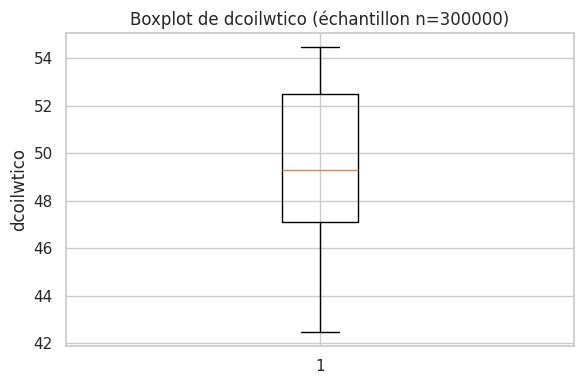

In [155]:
col = "dcoilwtico"
s = train_final.select(col).to_series().drop_nulls()

# échantillon pour que ça tourne vite
n = min(300_000, s.len())
samp = s.sample(n=n, seed=42) if s.len() > n else s

plt.figure(figsize=(6,4))
plt.boxplot(samp.to_numpy(), vert=True, showfliers=True)
plt.title(f"Boxplot de {col} (échantillon n={samp.len()})")
plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Aucun outlier pour "dcoilwtico"

# EDA

In [156]:
# Importing the relevant libraries
import IPython.display
import json
import pandas as pd
import seaborn as sns
import squarify
%matplotlib inline
import missingno as msno
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
import numpy as np
from matplotlib import pyplot as plt
color = sns.color_palette()

# D3 modules
from IPython.core.display import display, HTML, Javascript
from string import Template

In [157]:
def to_pd(df):
    # df : Polars DataFrame ou LazyFrame
    if isinstance(df, pl.LazyFrame):
        df = df.collect()
    return df.to_pandas()


********Représentativité des villes dans les occurences des magasins********

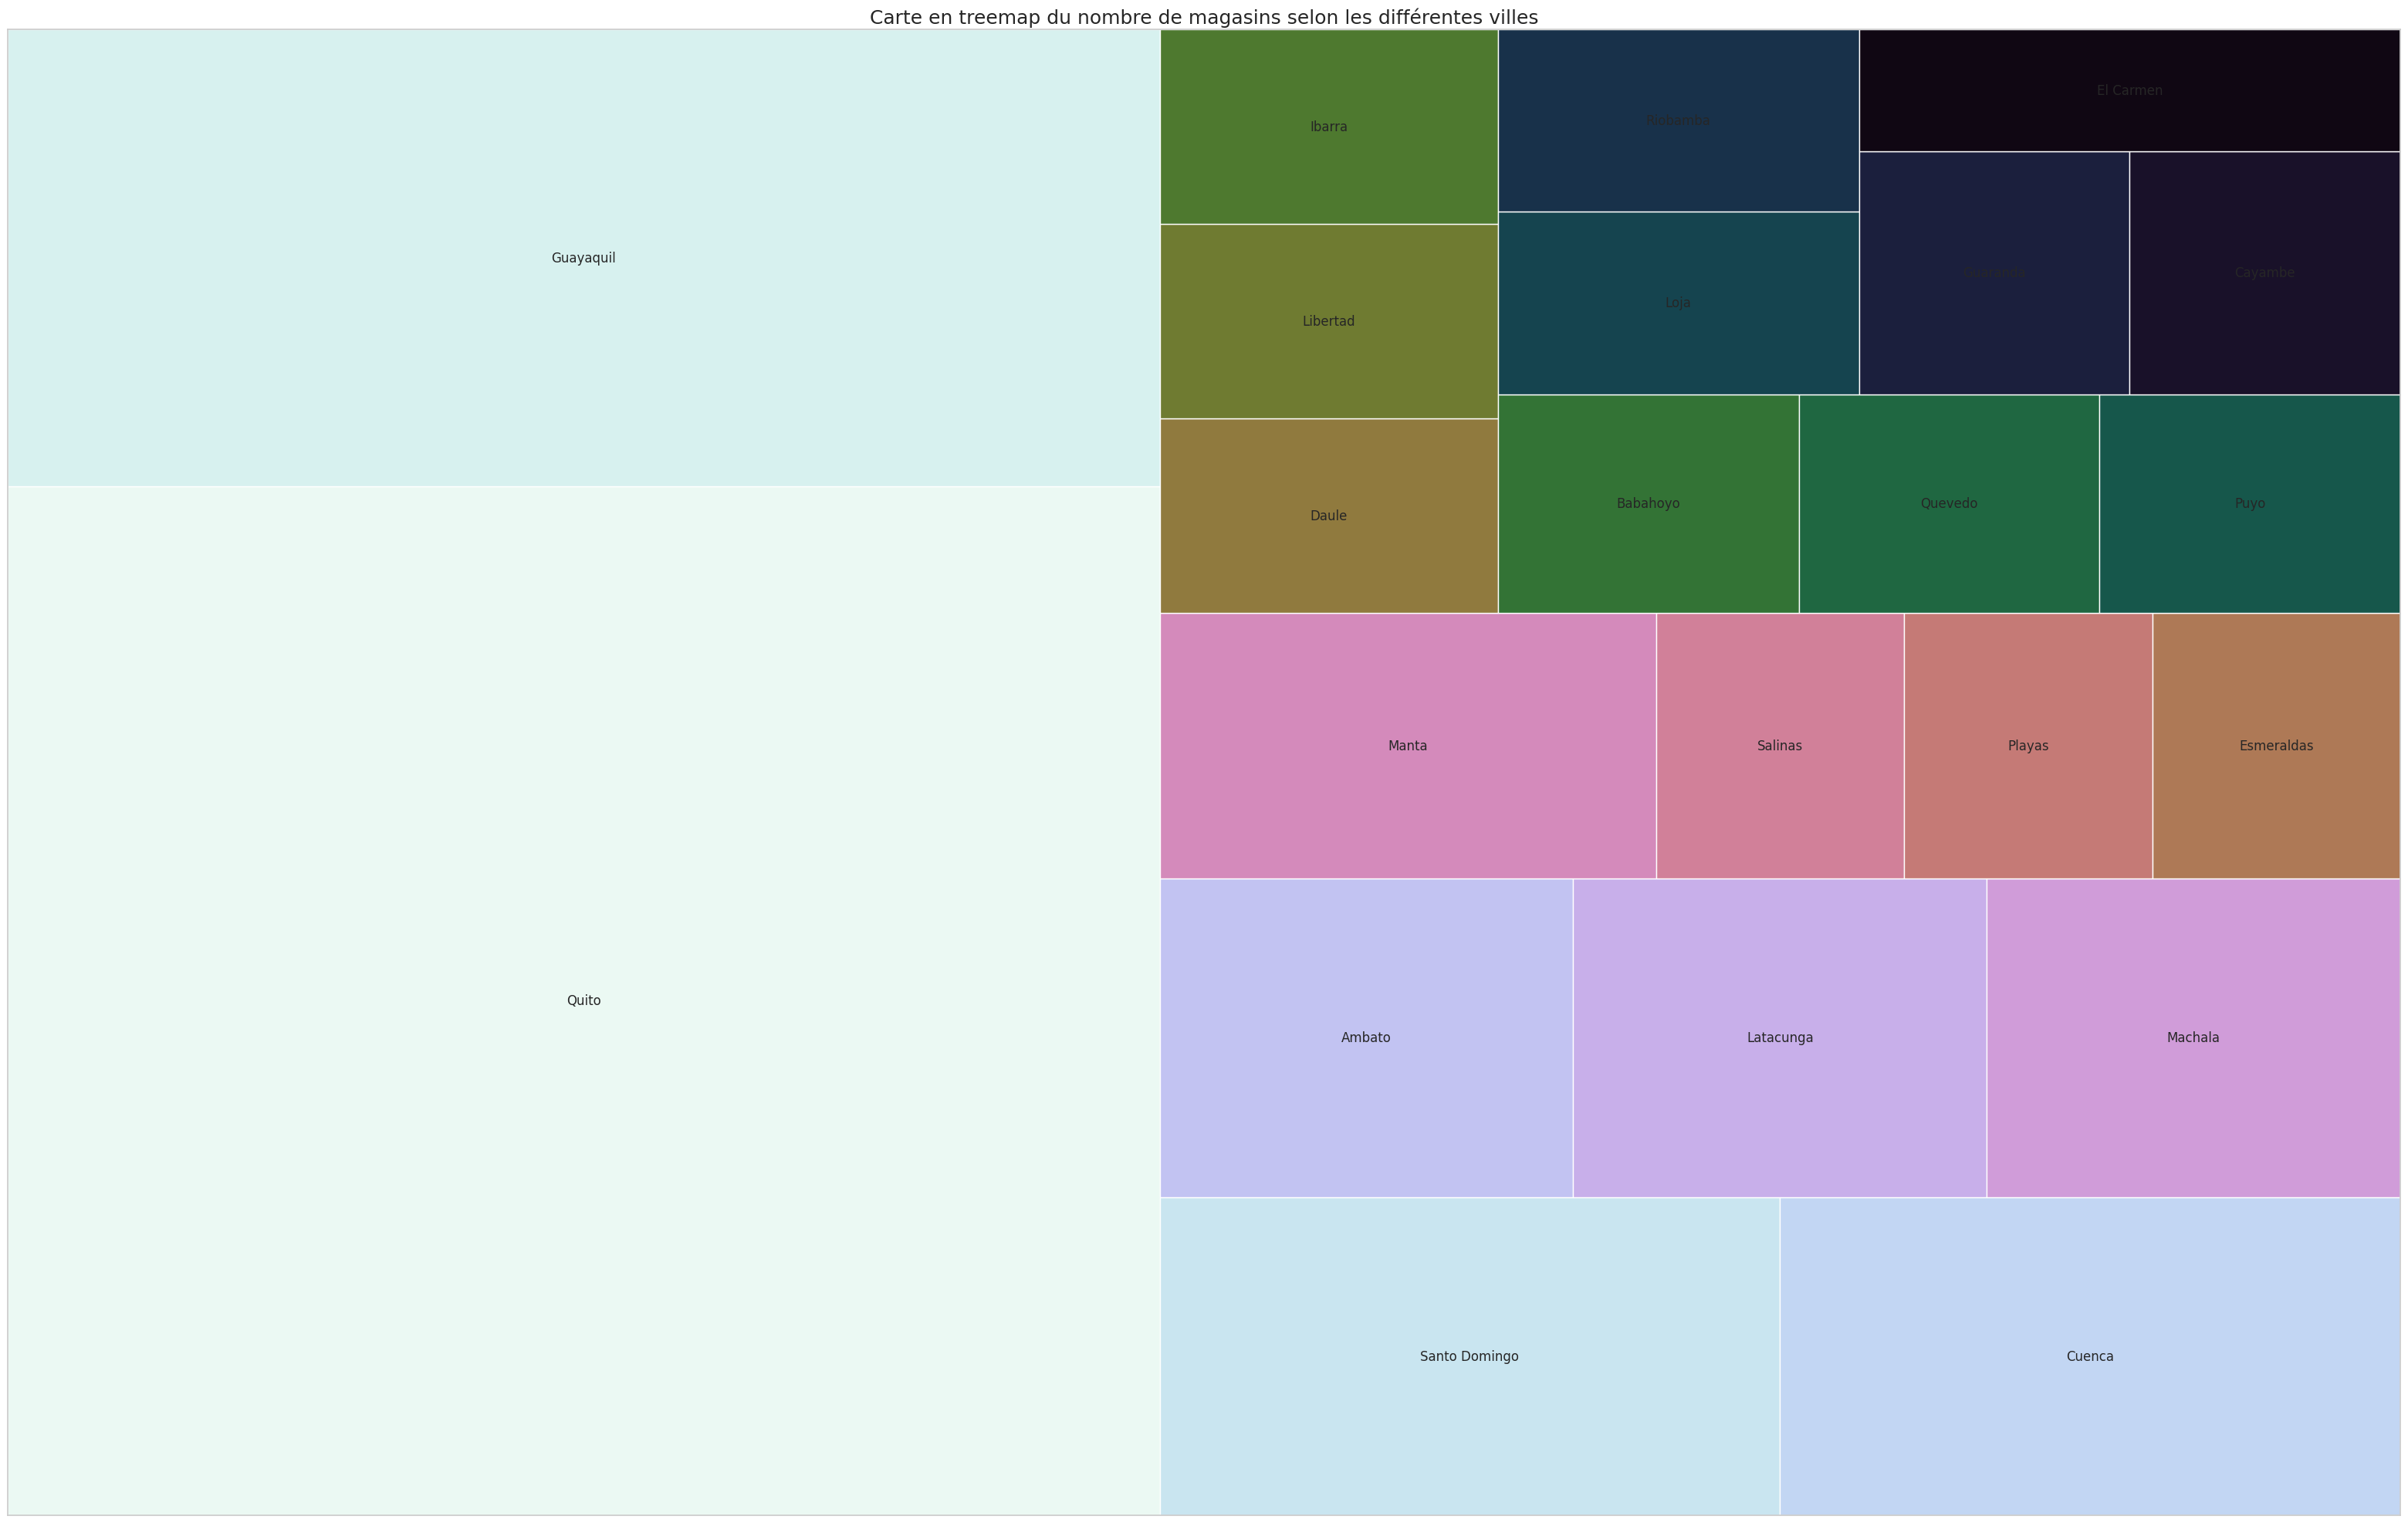

In [158]:
# value_counts en polars => colonnes: ["city", "count"]
marrimeko = (
    stores.get_column("city")
          .value_counts()
          .sort("count", descending=True)
)

sizes  = marrimeko["count"].to_list()
labels = marrimeko["city"].to_list()

fig, ax = plt.subplots(figsize=(40, 25))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=sns.color_palette("cubehelix_r", len(sizes)),  # pas 28 fixe
    alpha=1,
    ax=ax
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Carte en treemap du nombre de magasins selon les différentes villes", fontsize=18)
plt.show()


****Représentativité des Etats dans les occurences des magasins****

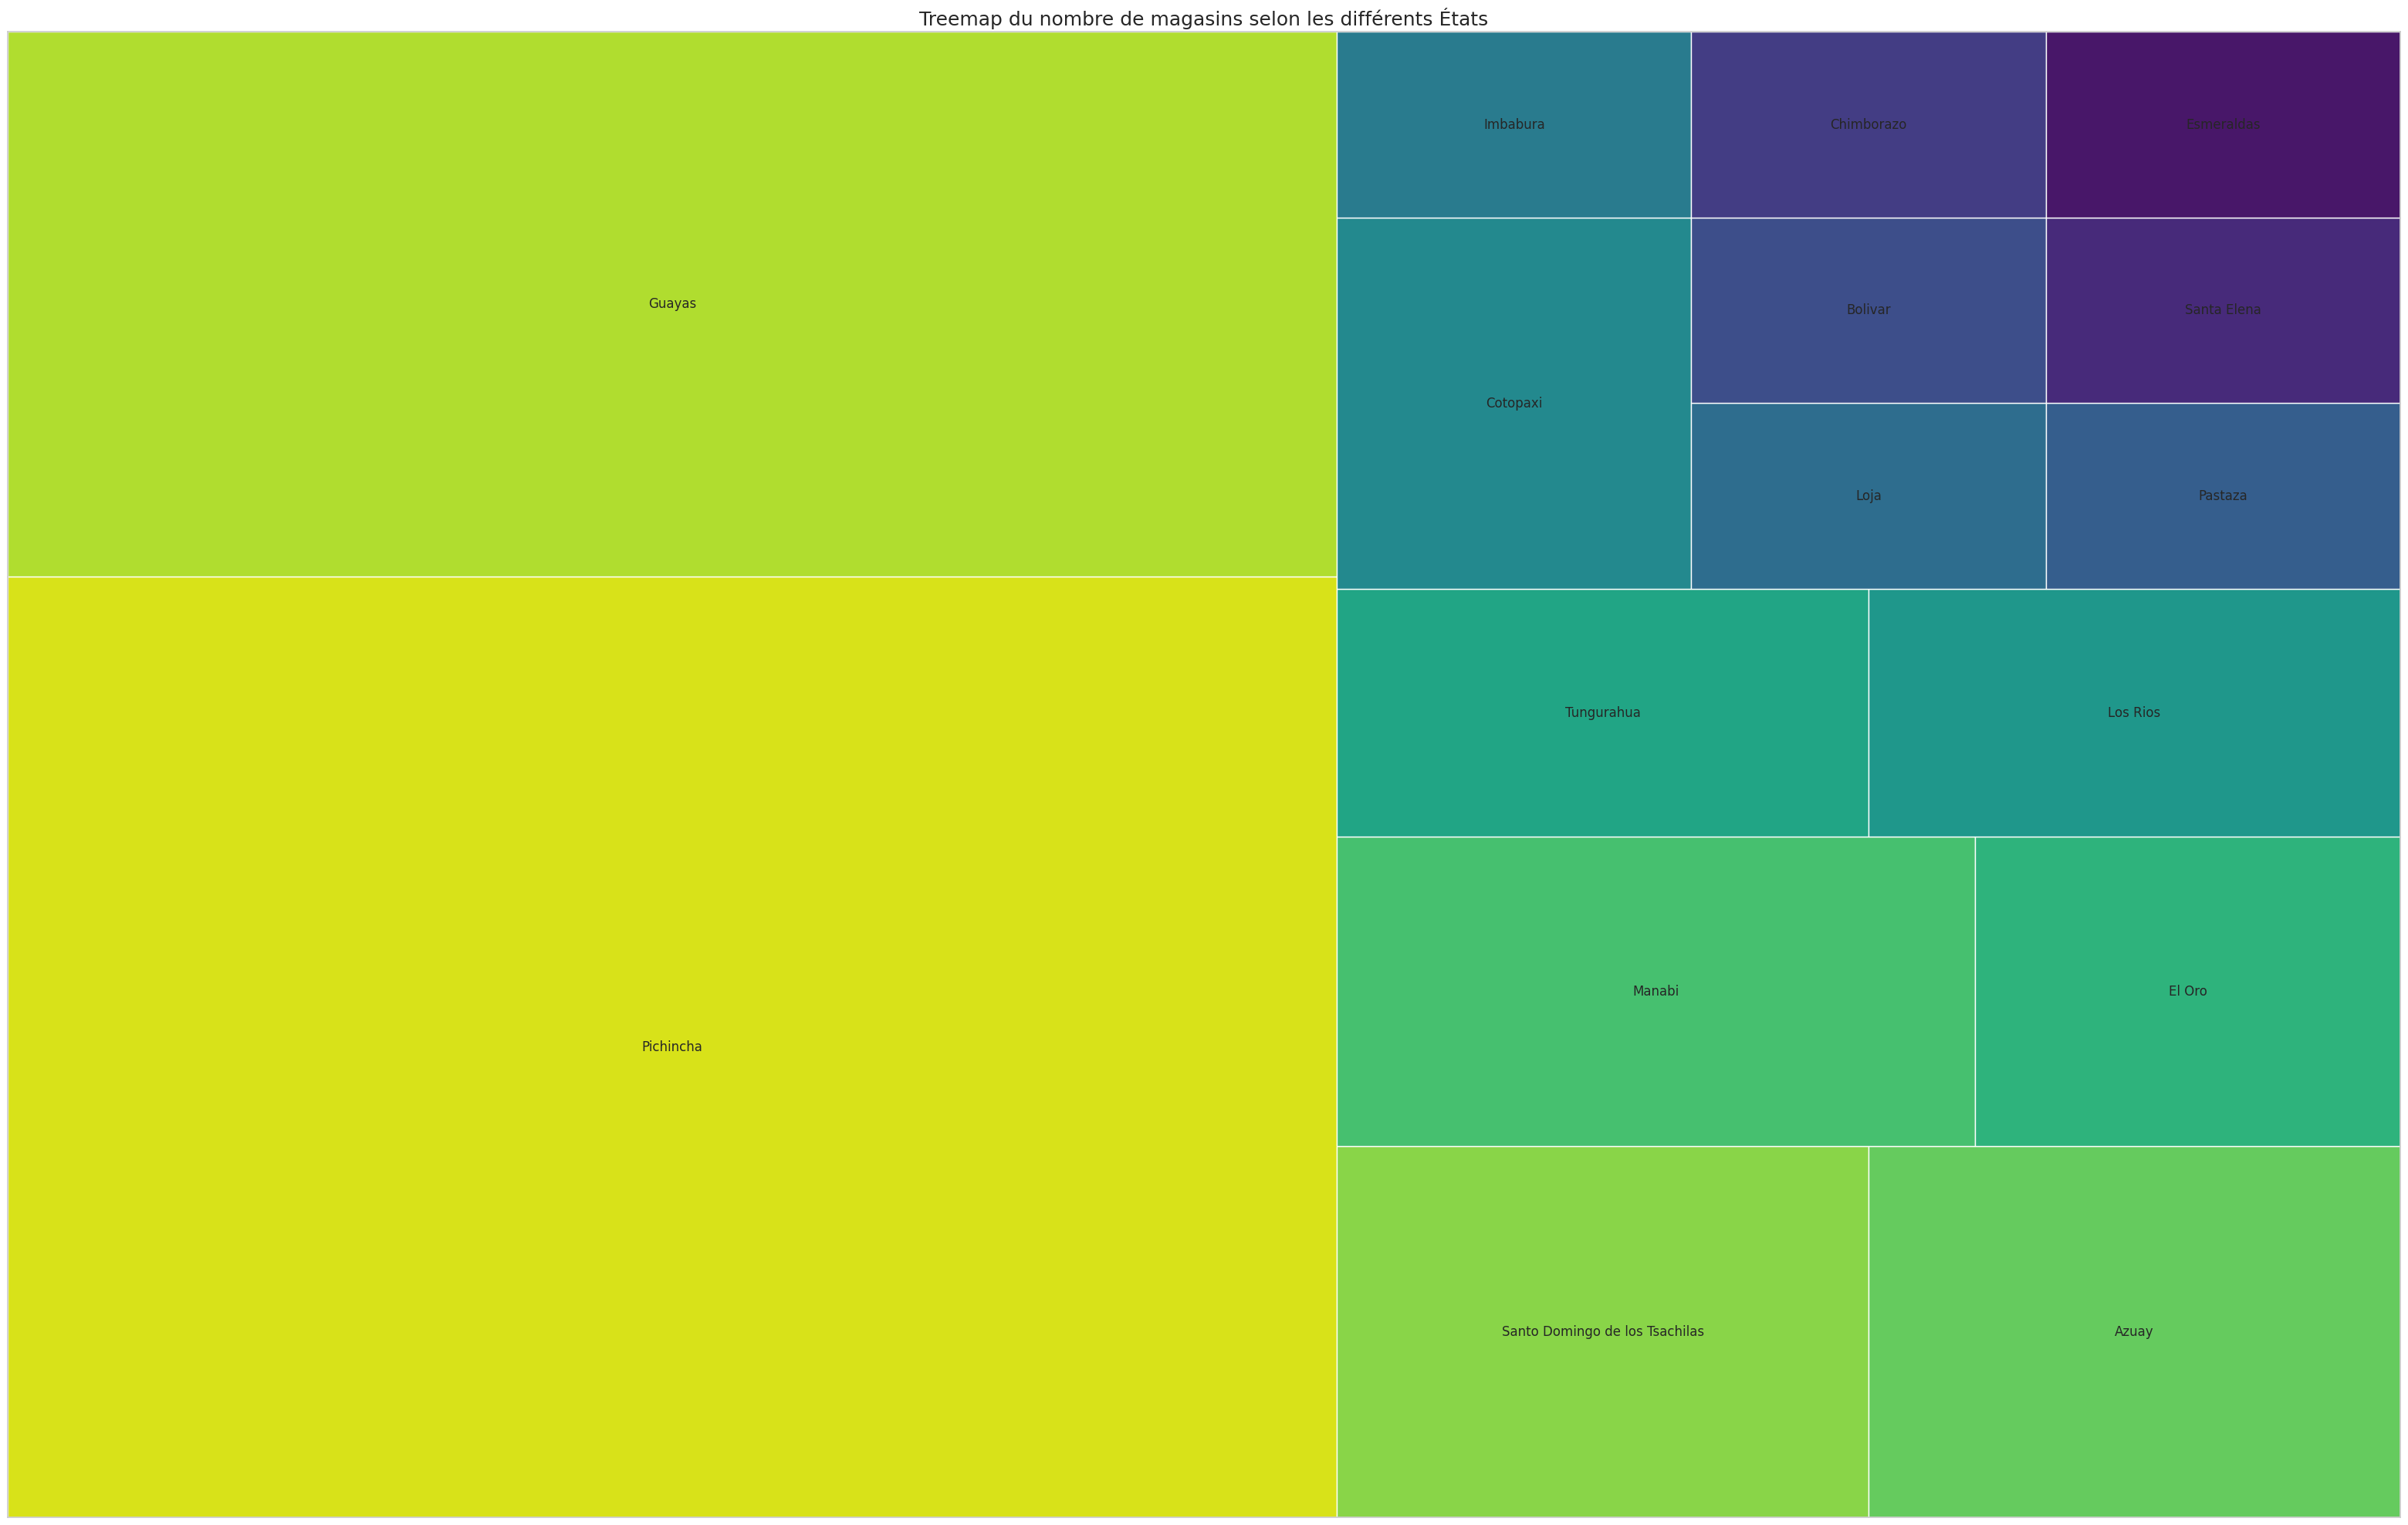

In [159]:
marrimeko = (
    stores.get_column("state")
          .value_counts()
          .sort("count", descending=True)
)

sizes  = marrimeko["count"].to_list()
labels = marrimeko["state"].to_list()

fig, ax = plt.subplots(figsize=(40, 25))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=sns.color_palette("viridis_r", len(sizes)),
    alpha=1,
    ax=ax
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Treemap du nombre de magasins selon les différents États", fontsize=18)
plt.show()


In [160]:
stores.get_column("state").unique()

state
str
"""Esmeraldas"""
"""Santo Domingo de los Tsachilas"""
"""Manabi"""
"""Guayas"""
"""Santa Elena"""
…
"""Imbabura"""
"""Chimborazo"""
"""El Oro"""


****Clusters de magasins par ville****

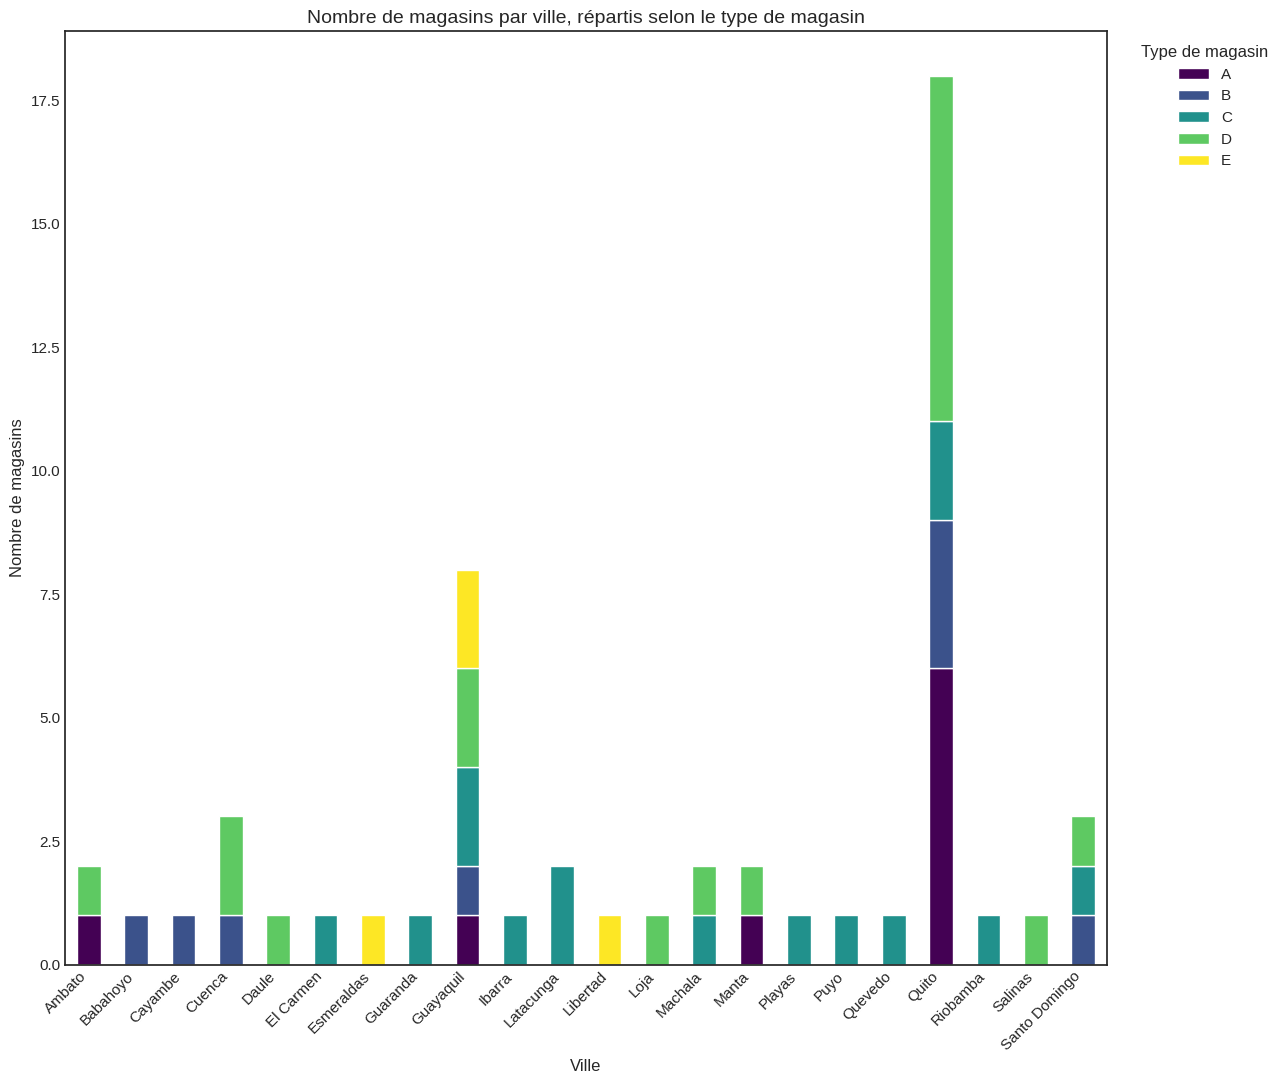

In [161]:

plt.style.use("seaborn-v0_8-white")  # style "seaborn-white" (version récente)

# Si stores est en Polars, convertis en pandas pour groupby/unstack/plot
stores_pd = stores.to_pandas()

city_type_counts = (
    stores_pd
    .groupby(["city", "type"])["store_nbr"]
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = city_type_counts.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    figsize=(13, 11),
    grid=False
)

ax.set_title("Nombre de magasins par ville, répartis selon le type de magasin", fontsize=14)
ax.set_xlabel("Ville")
ax.set_ylabel("Nombre de magasins")
ax.legend(title="Type de magasin", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Holiday Events Data

In [162]:
holidays.head(3)

type,locale,locale_name,description,transferred,__date_tmp,date
str,str,str,str,bool,date,date
"""Holiday""","""National""","""Ecuador""","""Primer dia del ano""",true,2017-01-01,2017-01-01
"""Transfer""","""National""","""Ecuador""","""Traslado Primer dia del ano""",false,2017-01-02,2017-01-02
"""Holiday""","""National""","""Ecuador""","""Carnaval""",false,2017-02-27,2017-02-27


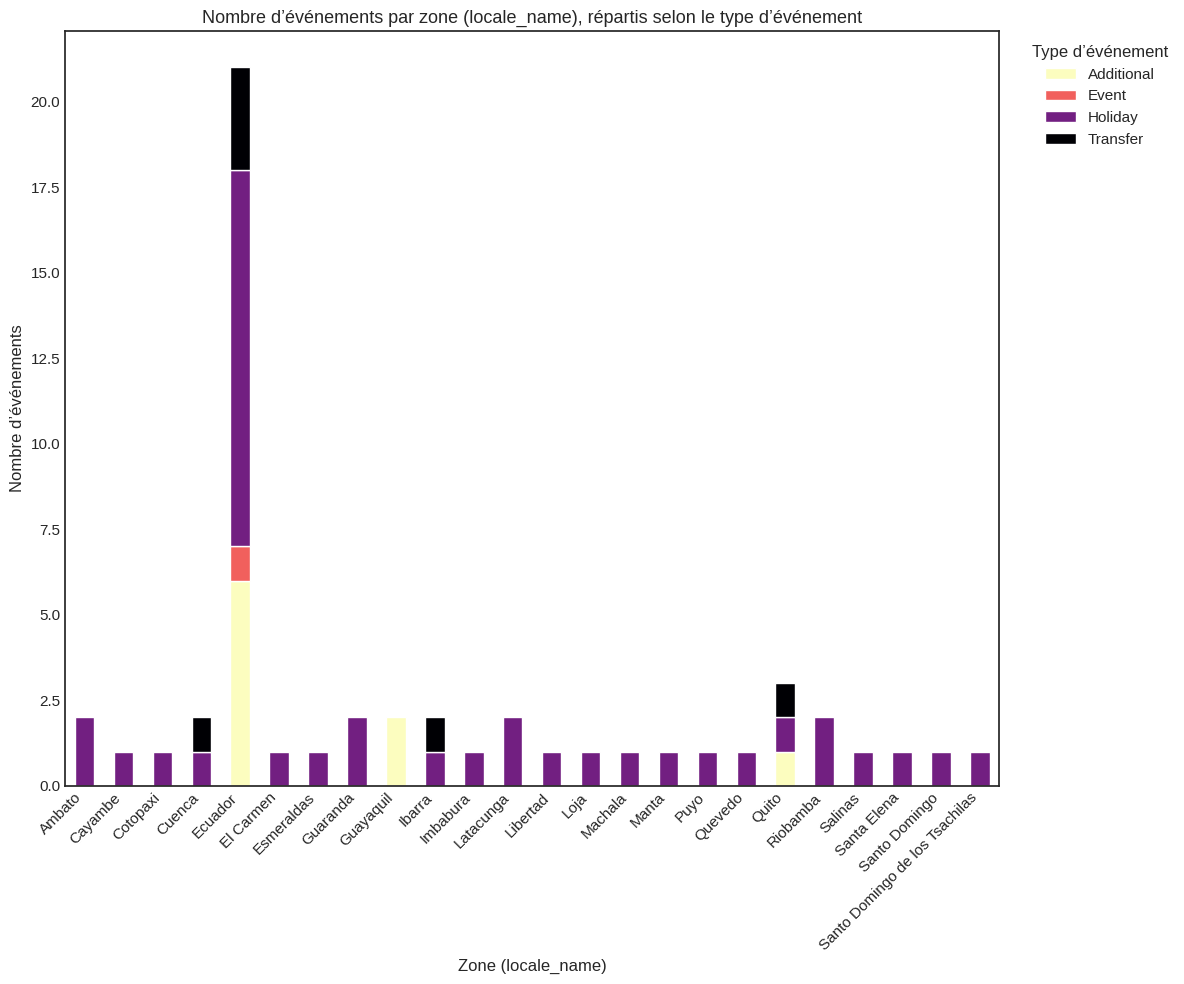

In [163]:
plt.style.use("seaborn-v0_8-white")

# Si holiday_events est en Polars
holiday_pd = holidays.to_pandas()

locale_type_counts = (
    holiday_pd
    .groupby(["locale_name", "type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = locale_type_counts.plot(
    kind="bar",
    stacked=True,
    colormap="magma_r",
    figsize=(12, 10),
    grid=False
)

ax.set_title("Nombre d’événements par zone (locale_name), répartis selon le type d’événement", fontsize=13)
ax.set_xlabel("Zone (locale_name)")
ax.set_ylabel("Nombre d’événements")
ax.legend(title="Type d’événement", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Transactions 

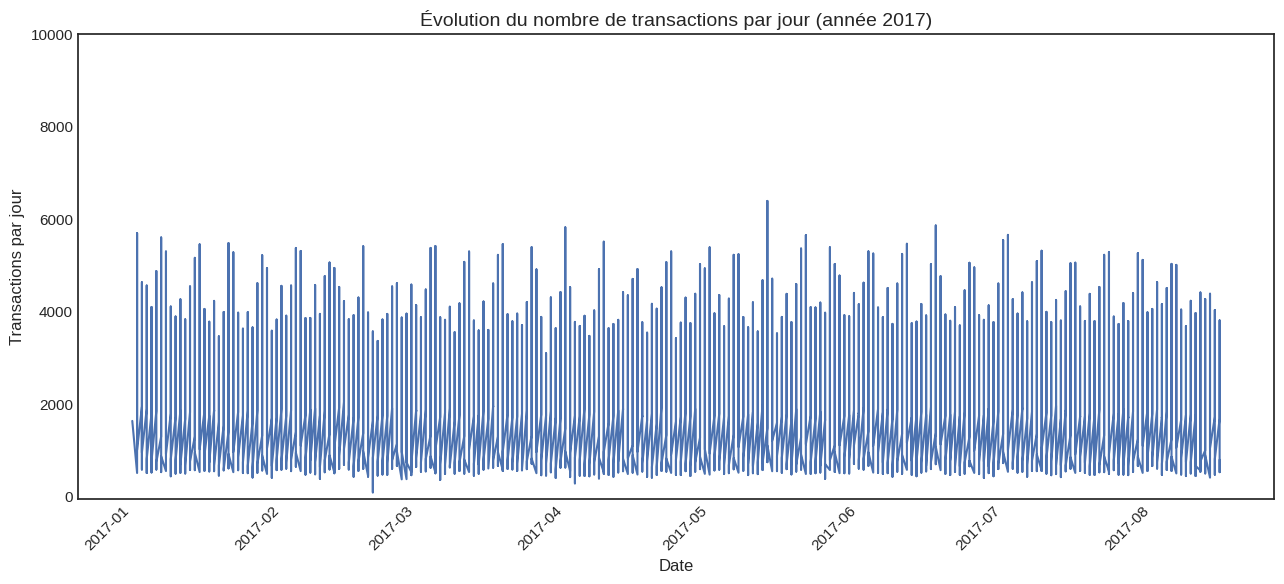

In [164]:

plt.style.use("seaborn-v0_8-white")

# Si transactions est en Polars :
tx = transactions.sort("date").to_pandas()

plt.figure(figsize=(13, 6))
plt.plot(tx["date"], tx["transactions"])  # pas besoin de .values

plt.ylim(-50, 10000)  # garde si tu veux forcer l'échelle
plt.title("Évolution du nombre de transactions par jour (année 2017)", fontsize=14)
plt.ylabel("Transactions par jour", fontsize=12)
plt.xlabel("Date", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


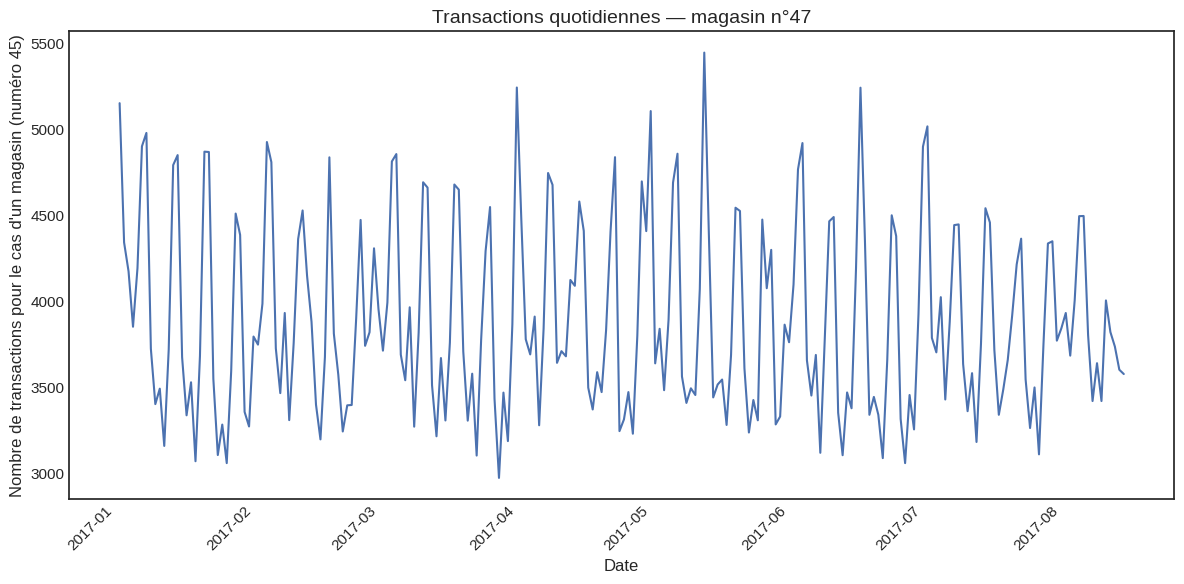

In [165]:
store_id = 47

ts = (
    transactions
    .filter(pl.col("store_nbr") == store_id)
    .select(["date", "transactions"])
    .drop_nulls()
    .sort("date")
    .with_columns(pl.col("transactions").cast(pl.Float64))
    .to_pandas()
)

plt.figure(figsize=(12, 6))
plt.plot(ts["date"], ts["transactions"])
plt.title(f"Transactions quotidiennes — magasin n°{store_id}", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Nombre de transactions pour le cas d'un magasin (numéro 45)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


****Items data****

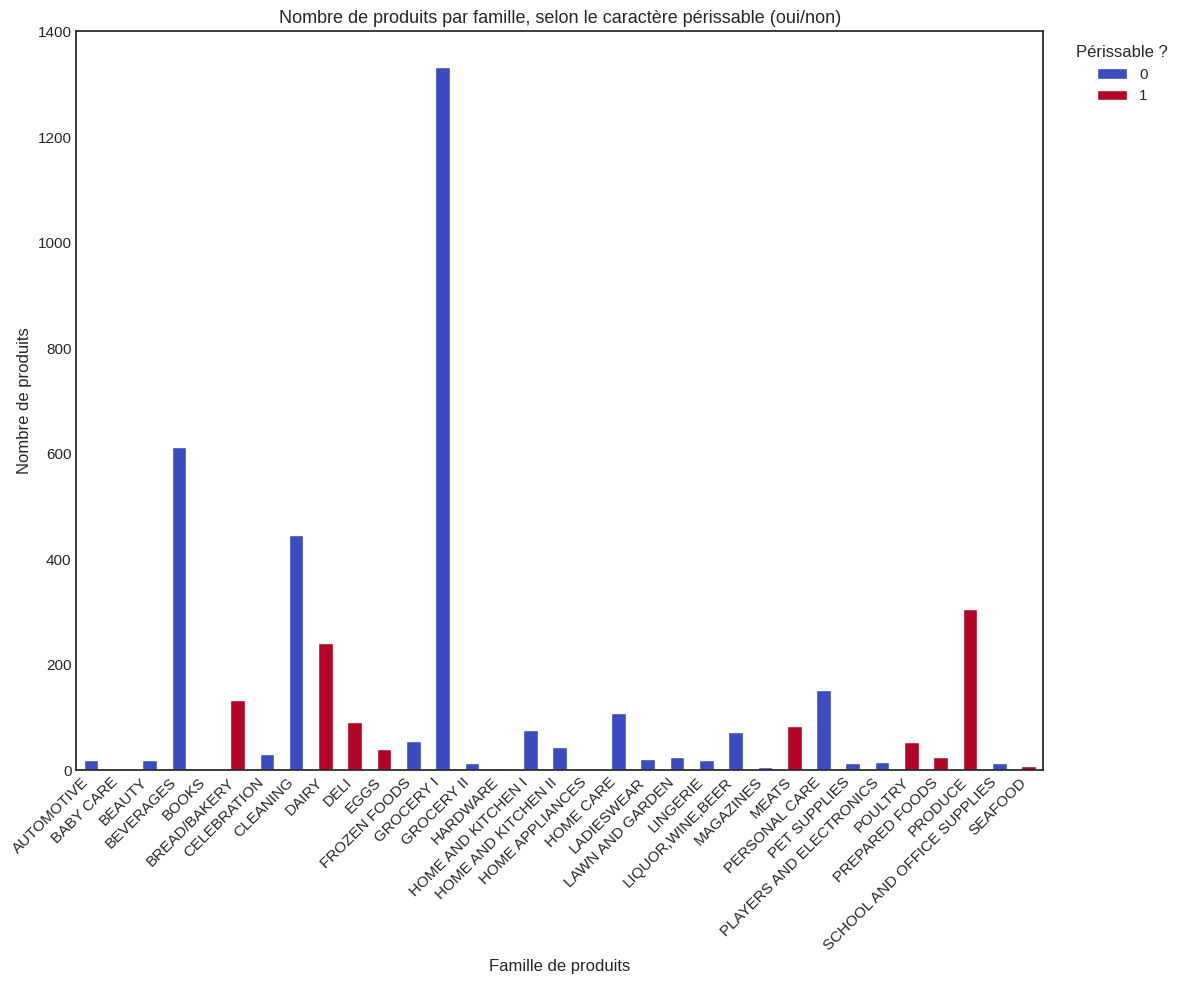

In [166]:
plt.style.use("seaborn-v0_8-white")

# Si items est en Polars
items_pd = items.to_pandas()

fam_perishable = (
    items_pd
    .groupby(["family", "perishable"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = fam_perishable.plot(
    kind="bar",
    stacked=True,
    colormap="coolwarm",
    figsize=(12, 10),
    grid=False
)

ax.set_title("Nombre de produits par famille, selon le caractère périssable (oui/non)", fontsize=13)
ax.set_xlabel("Famille de produits")
ax.set_ylabel("Nombre de produits")
ax.legend(title="Périssable ?", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Training Data

In [167]:
train.head(5)

id,store_nbr,item_nbr,unit_sales,onpromotion,date
i64,i64,i64,f64,str,date
101688779,25,99197,1.0,"""False""",2017-01-01
101688780,25,103665,7.0,"""False""",2017-01-01
101688781,25,105574,1.0,"""False""",2017-01-01
101688782,25,105857,4.0,"""False""",2017-01-01
101688783,25,106716,2.0,"""False""",2017-01-01


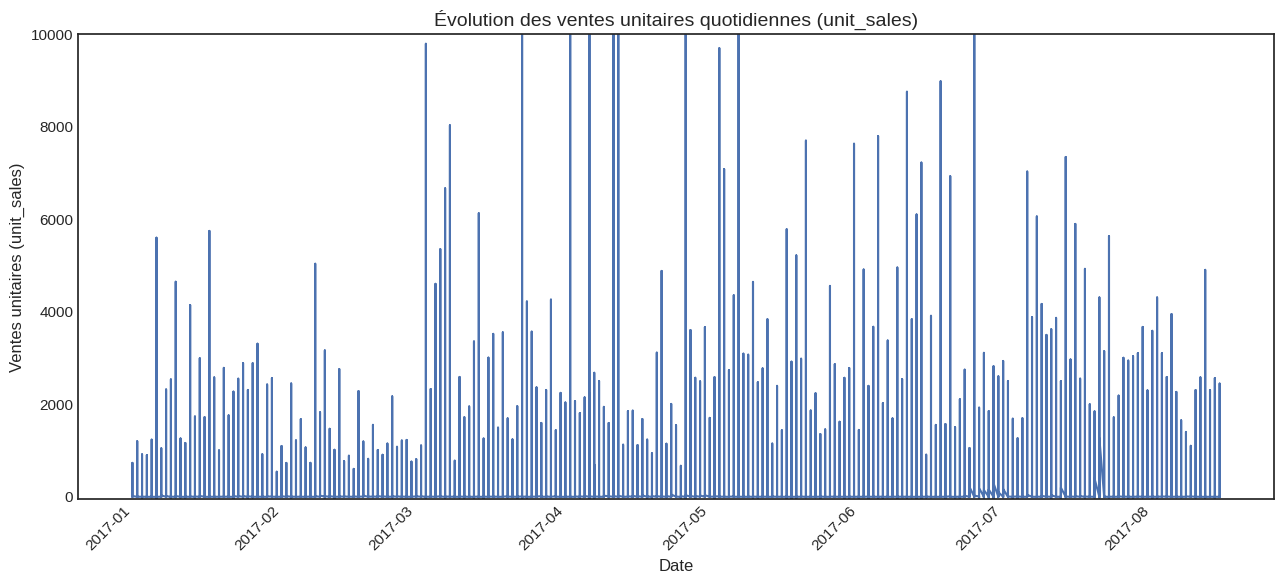

In [168]:
plt.style.use("seaborn-v0_8-deep")

# Si train est en Polars
tr = train.sort("date").to_pandas()

plt.figure(figsize=(13, 6))
plt.plot(tr["date"], tr["unit_sales"])

plt.ylim(-50, 10000)  # garde si tu veux forcer l’échelle
plt.title("Évolution des ventes unitaires quotidiennes (unit_sales)", fontsize=14)
plt.ylabel("Ventes unitaires (unit_sales)")
plt.xlabel("Date")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


****Série temporelle : ventes totales par jour (tendance globale)****

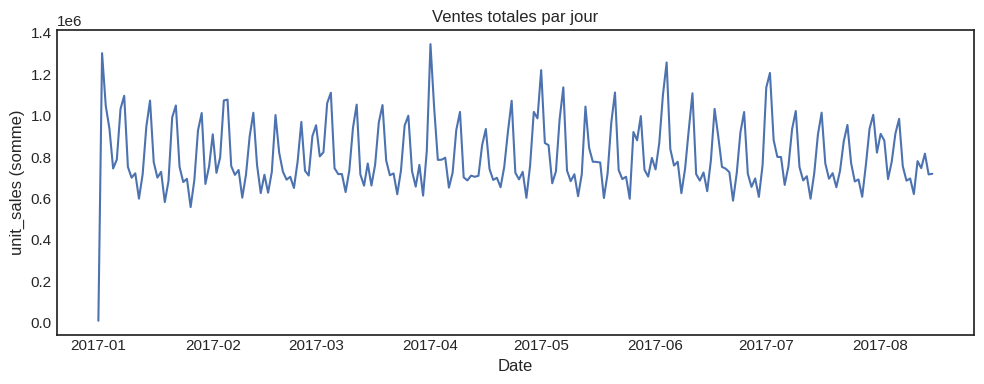

In [169]:


daily = (train_final
         .group_by("date")
         .agg(pl.col("unit_sales").sum().alias("sales"))
         .sort("date"))

d = daily.to_pandas()
d["date"] = pd.to_datetime(d["date"])   # <- important

plt.figure(figsize=(10,4))
plt.plot(d["date"], d["sales"])
plt.title("Ventes totales par jour")
plt.xlabel("Date"); plt.ylabel("unit_sales (somme)")
plt.tight_layout(); plt.show()




****Transactions : relation “fréquentation magasin” vs ventes****

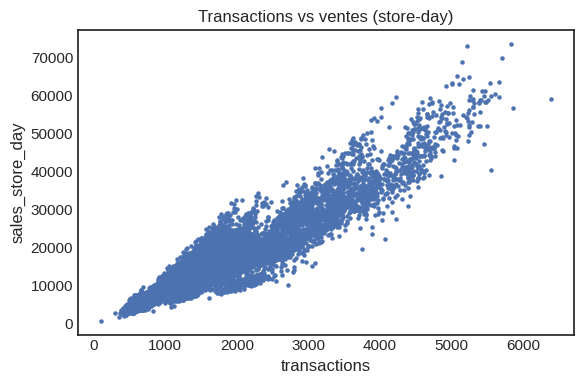

In [170]:
ds = (train_final
      .group_by(["date","store_nbr"])
      .agg(pl.col("unit_sales").sum().alias("sales_store_day"),
           pl.col("transactions").max().alias("transactions"))  # identique par store/date
      .drop_nulls(["transactions"]))

d = to_pd(ds.sample(n=min(200_000, ds.height), seed=42))
plt.figure(figsize=(6,4))
plt.scatter(d["transactions"], d["sales_store_day"], s=5)
plt.title("Transactions vs ventes (store-day)")
plt.xlabel("transactions"); plt.ylabel("sales_store_day")
plt.tight_layout(); plt.show()


****Oil : le pétrole bouge-t-il avec les ventes ?****

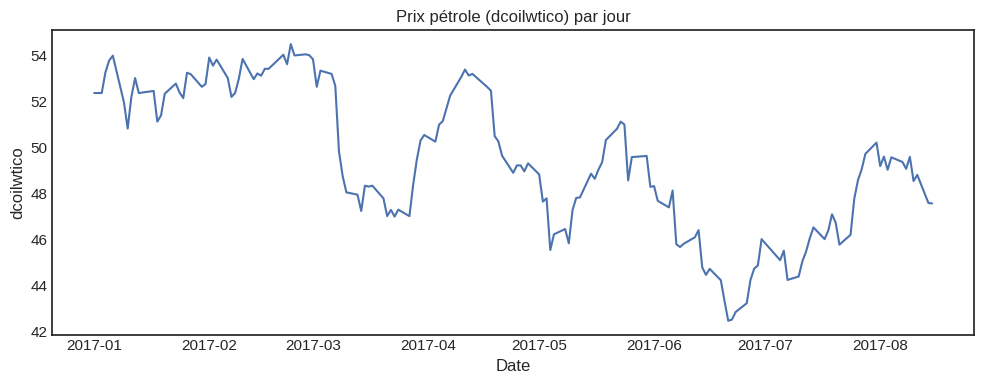

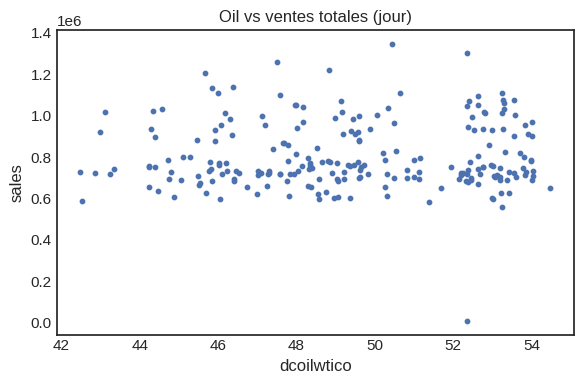

In [171]:
oil_daily = (train_final
             .group_by("date")
             .agg(pl.col("unit_sales").sum().alias("sales"),
                  pl.col("dcoilwtico").max().alias("oil"))
             .drop_nulls(["oil"])
             .sort("date"))

d = to_pd(oil_daily)

plt.figure(figsize=(10,4))
plt.plot(d["date"], d["oil"])
plt.title("Prix pétrole (dcoilwtico) par jour")
plt.xlabel("Date"); plt.ylabel("dcoilwtico")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.scatter(d["oil"], d["sales"], s=10)
plt.title("Oil vs ventes totales (jour)")
plt.xlabel("dcoilwtico"); plt.ylabel("sales")
plt.tight_layout(); plt.show()


****Holidays : ventes jours “avec événement” vs “sans”****

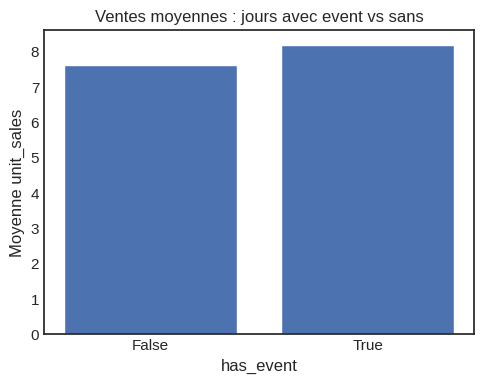

In [172]:
hol_effect = (train_final
              .with_columns((pl.col("n_events_total") > 0).alias("has_event"))
              .group_by("has_event")
              .agg(pl.col("unit_sales").mean().alias("avg_sales"),
                   pl.col("unit_sales").median().alias("med_sales"),
                   pl.len().alias("n_rows"))
              .sort("has_event"))

d = to_pd(hol_effect)
plt.figure(figsize=(5,4))
plt.bar(d["has_event"].astype(str), d["avg_sales"])
plt.title("Ventes moyennes : jours avec event vs sans")
plt.xlabel("has_event"); plt.ylabel("Moyenne unit_sales")
plt.tight_layout(); plt.show()


****Hétérogénéité magasins : top 15 des stores qui vendent le plus****

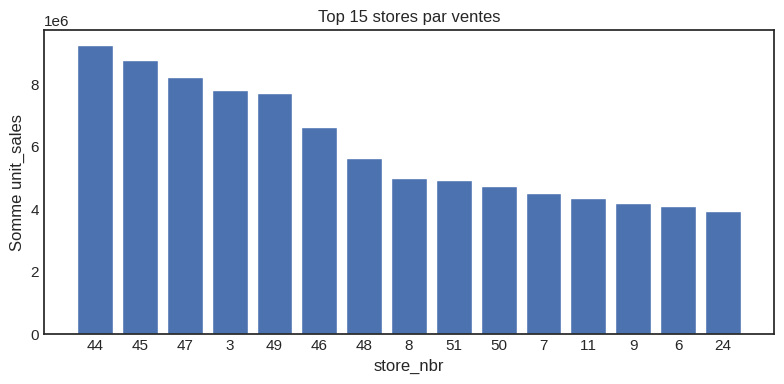

In [173]:
top_store = (train_final
             .group_by("store_nbr")
             .agg(pl.col("unit_sales").sum().alias("sales"))
             .sort("sales", descending=True)
             .head(15))

d = to_pd(top_store)
plt.figure(figsize=(8,4))
plt.bar(d["store_nbr"].astype(str), d["sales"])
plt.title("Top 15 stores par ventes")
plt.xlabel("store_nbr"); plt.ylabel("Somme unit_sales")
plt.tight_layout(); plt.show()


****Ventes totales par les types de stores (clusters prévus par les données)****

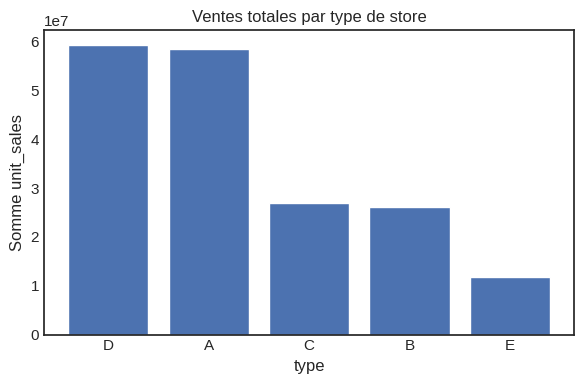

In [174]:
by_type = (train_final
           .group_by("type")
           .agg(pl.col("unit_sales").sum().alias("sales"))
           .sort("sales", descending=True))

d = to_pd(by_type)
plt.figure(figsize=(6,4))
plt.bar(d["type"], d["sales"])
plt.title("Ventes totales par type de store")
plt.xlabel("type"); plt.ylabel("Somme unit_sales")
plt.tight_layout(); plt.show()
